# 🚀 JOBIO — BÁO CÁO ĐÁNH GIÁ ĐỘ CHÍNH XÁC & ỔN ĐỊNH HỆ THỐNG EMBEDDING & MATCHING 

## Hybrid Semantic-Structured Job Recommendation & CV Matching Engine

---
## PHẦN 0: THIẾT LẬP MÔI TRƯỜNG & CẤU HÌNH CHUNG



In [1]:
# ---------------------------------------------------------------------------
# 0.1 THIẾT LẬP MÔI TRƯỜNG & KHỞI TẠO DJANGO
# ---------------------------------------------------------------------------
import os
import sys
import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from concurrent.futures import ThreadPoolExecutor
from types import SimpleNamespace
from dotenv import load_dotenv

# Thiết lập đường dẫn backend và nạp .env
current_dir = Path(os.getcwd()).resolve()
backend_dir = (
    current_dir
    if current_dir.name == "backend"
    else current_dir.parent
    if current_dir.parent.name == "backend"
    else current_dir / "backend"
)
if str(backend_dir) not in sys.path:
    sys.path.insert(0, str(backend_dir))

env_path = backend_dir / ".env"
if env_path.exists():
    load_dotenv(dotenv_path=env_path, override=True)

os.environ.setdefault("DJANGO_SETTINGS_MODULE", "config.settings")
os.environ["DJANGO_ALLOW_ASYNC_UNSAFE"] = "true"
os.environ["DEBUG"] = os.getenv("DEBUG", "1")
if not os.getenv("SECRET_KEY") or os.getenv("SECRET_KEY").startswith(
    "django-insecure-"
):
    os.environ["SECRET_KEY"] = (
        "django-insecure-eval-notebook-key-0123456789abcdefghijklmnopqrstuvwxyz"
    )

import django  # noqa: E402

django.setup()

# Cấu hình giao diện biểu đồ
plt.style.use(
    "seaborn-v0_8-whitegrid"
    if "seaborn-v0_8-whitegrid" in plt.style.available
    else "default"
)
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["figure.titlesize"] = 15
plt.rcParams["figure.dpi"] = 120

print(f"✅ Môi trường Django ({os.environ.get('DJANGO_SETTINGS_MODULE')}) đã sẵn sàng!")

✅ Môi trường Django (config.settings) đã sẵn sàng!


### 0.2 Cấu hình theo thông tin thật bạn đã cung cấp


In [2]:
# ---------------------------------------------------------------------------
# 0.2 CẤU HÌNH MODEL & SERVICE CHUẨN XÁC THEO SCHEMA JOBIO
# ---------------------------------------------------------------------------
import traceback
from django.conf import settings
from apps.candidate.recruiters.models import Recruiter
from apps.candidate.recruiter_skills.models import RecruiterSkill
from apps.recruitment.jobs.models import (
    Job,
    JobEmbedding,
    CandidateRecommendationEmbedding,
)
from apps.recruitment.applications.models import Application
from apps.recruitment.job_categories.models import JobCategory
from apps.recruitment.jobs.services.recommendations import (
    MODEL_VERSION,
    DEFAULT_EMBEDDING_DIMENSIONS,
    _get_sentence_transformer,
    _calibrated_semantic_score,
    _calculate_penalty_multiplier,
    _extract_candidate_data,
    _factor_scores,
    _eligible_jobs,
    _semantic_recall,
    _structured_recall_ids,
    _fallback_job_ids,
    _ordered_unique,
    score_candidate_job,
    recommend_jobs_for_recruiter,
)

CANDIDATE_MODEL = Recruiter
JOB_MODEL = Job
JOB_EMBEDDING_MODEL = JobEmbedding
CANDIDATE_EMBEDDING_MODEL = CandidateRecommendationEmbedding
APPLICATION_MODEL = Application
JOB_CATEGORY_MODEL = JobCategory
RECRUITER_SKILL_MODEL = RecruiterSkill

CANDIDATE_EMBEDDING_FIELD = "embedding"
JOB_EMBEDDING_FIELD = "embedding"
JOB_EMBEDDING_FK = "job_id"
CANDIDATE_EMBEDDING_RECRUITER_FK = "recruiter_id"
CANDIDATE_EMBEDDING_RECRUITER_CV_FK = "cv_id"
JOB_DOMAIN_PATH = "category__domain"
JOB_CATEGORY_PATH = "category__name"
CANDIDATE_DOMAIN_INFERENCE = "skill_majority"

# Trạng thái Application chuẩn cho Ground Truth
POSITIVE_STATUSES_STRICT = ["shortlisted", "interview", "offered", "accepted"]
HARD_NEGATIVE_STATUSES = ["rejected"]
RELEVANCE_GRADE = {
    "offered": 3,
    "accepted": 3,
    "shortlisted": 2,
    "interview": 2,
    "reviewing": 1,
    "pending": 1,
    "rejected": -1,
}

SCORE_FN_HYBRID = score_candidate_job
MIN_CANDIDATES_FOR_VALID_EVAL = 30

print("✅ Đã kết nối đầy đủ Models và Services của JOBIO:")
print(
    f"  - Matching Model Version: {MODEL_VERSION} | Embedding Dimensions: {DEFAULT_EMBEDDING_DIMENSIONS}"
)
print(
    f"  - Embedding Provider (Settings): {getattr(settings, 'RECOMMENDATION_EMBEDDING_PROVIDER', 'local')}"
)
print(
    f"  - Embedding Model (Settings): {getattr(settings, 'RECOMMENDATION_EMBEDDING_MODEL', 'BAAI/bge-m3')}"
)
print(
    f"  - Thống kê DB thật: {CANDIDATE_MODEL.objects.count()} Candidates, {JOB_MODEL.objects.count()} Jobs, {APPLICATION_MODEL.objects.count()} Applications"
)

✅ Đã kết nối đầy đủ Models và Services của JOBIO:
  - Matching Model Version: hybrid-v2-1024 | Embedding Dimensions: 1024
  - Embedding Provider (Settings): local
  - Embedding Model (Settings): BAAI/bge-m3
  - Thống kê DB thật: 6 Candidates, 153 Jobs, 0 Applications


---
## PHẦN 1: TOÀN VẸN VECTOR & ĐỘ TRỄ TRUY VẤN — TRÊN DỮ LIỆU THẬT

### 1.0 Chẩn đoán Live Model Provider & Phân tích Nguồn Vector trong DB
Mục tiêu: Xác định chính xác model embedding đang hoạt động thật (`BAAI/bge-m3`) hay bị fallback sang `FakeEmbeddingProvider` (băm SHA-256 giả ngẫu nhiên).


In [3]:
# ---------------------------------------------------------------------------
# 1.0 CHẨN ĐOÁN LIVE MODEL PROVIDER VÀ PHÂN TÍCH DB
# ---------------------------------------------------------------------------

print("=== 1. KIỂM TRA METADATA EMBEDDING TRONG DATABASE ===")
job_sample_embs = list(
    JOB_EMBEDDING_MODEL.objects.values(
        "model", "model_version", "status", "dimensions"
    )[:5]
)
cand_sample_embs = list(
    CANDIDATE_EMBEDDING_MODEL.objects.values(
        "model", "model_version", "status", "dimensions"
    )[:5]
)

print(f"JobEmbedding sample metadata: {job_sample_embs}")
print(f"CandidateEmbedding sample metadata: {cand_sample_embs}")

print("\n=== 2. TEST TRỰC TIẾP MODEL EMBEDDING PROVIDER ===")
configured_model = getattr(settings, "RECOMMENDATION_EMBEDDING_MODEL", "BAAI/bge-m3")
is_model_live = False

try:
    live_model = _get_sentence_transformer(configured_model)
    test_text = "Senior Python Backend Developer with Django and PostgreSQL experience"
    test_vec = live_model.encode(
        test_text, normalize_embeddings=True, show_progress_bar=False
    )
    vec_dim = len(test_vec)
    vec_norm = float(np.linalg.norm(test_vec))
    print(f"✅ Model thật '{configured_model}' LOAD & ENCODE THÀNH CÔNG!")
    print(f"   - Vector Dimension: {vec_dim}")
    print(f"   - Vector L2-Norm: {vec_norm:.4f}")
    print(f"   - 5 chiều đầu: {np.round(test_vec[:5], 4).tolist()}")
    is_model_live = True
except Exception as e:
    print(f"❌ Model thật '{configured_model}' LOAD LỖI: {type(e).__name__}: {e}")
    print("   → Traceback chi tiết:")
    traceback.print_exc()
    print(
        "   ⚠️ Hệ thống đang fallback sang FakeEmbeddingProvider (sinh vector giả ngẫu nhiên từ SHA-256)."
    )

=== 1. KIỂM TRA METADATA EMBEDDING TRONG DATABASE ===
JobEmbedding sample metadata: [{'model': 'BAAI/bge-m3', 'model_version': 'hybrid-v2-1024', 'status': 'skipped', 'dimensions': 1024}, {'model': 'BAAI/bge-m3', 'model_version': 'hybrid-v2-1024', 'status': 'failed', 'dimensions': 1024}, {'model': 'BAAI/bge-m3', 'model_version': 'hybrid-v2-1024', 'status': 'ready', 'dimensions': 1024}, {'model': 'BAAI/bge-m3', 'model_version': 'hybrid-v2-1024', 'status': 'ready', 'dimensions': 1024}, {'model': 'BAAI/bge-m3', 'model_version': 'hybrid-v2-1024', 'status': 'ready', 'dimensions': 1024}]
CandidateEmbedding sample metadata: [{'model': 'BAAI/bge-m3', 'model_version': 'hybrid-v2-1024', 'status': 'ready', 'dimensions': 1024}, {'model': 'BAAI/bge-m3', 'model_version': 'hybrid-v2-1024', 'status': 'ready', 'dimensions': 1024}, {'model': 'BAAI/bge-m3', 'model_version': 'hybrid-v2-1024', 'status': 'ready', 'dimensions': 1024}, {'model': 'BAAI/bge-m3', 'model_version': 'hybrid-v2-1024', 'status': 'read

/Users/capkimkhanh/Documents/DUT3_2/JOBIO/backend/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO 2026-08-22 09:06:17,837 model No device provided, using mps
INFO 2026-08-22 09:06:18,259 _client HTTP Request: GET https://huggingface.co/api/agent-harnesses "HTTP/1.1 200 OK"
INFO 2026-08-22 09:06:18,516 _client HTTP Request: HEAD https://huggingface.co/BAAI/bge-m3/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
INFO 2026-08-22 09:06:18,553 _client HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/BAAI/bge-m3/5617a9f61b028005a4858fdac845db406aefb181/modules.json "HTTP/1.1 200 OK"
INFO 2026-08-22 09:06:18,807 _client HTTP Request: HEAD https://huggingface.co/BAAI/bge-m3/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
INFO 2026-08-22 09

✅ Model thật 'BAAI/bge-m3' LOAD & ENCODE THÀNH CÔNG!
   - Vector Dimension: 1024
   - Vector L2-Norm: 1.0000
   - 5 chiều đầu: [-0.05139999836683273, -0.03869999945163727, -0.04179999977350235, -0.014999999664723873, -0.015399999916553497]


In [4]:
# ---------------------------------------------------------------------------
# 1.1 LẤY EMBEDDING THẬT TỪ DB — Phân loại rõ Ready / Skipped / Failed / Pending
# ---------------------------------------------------------------------------
# Job Embeddings: Phân loại chi tiết theo status
job_embed_qs = list(
    JOB_EMBEDDING_MODEL.objects.values("job_id", JOB_EMBEDDING_FIELD, "status", "error")
)
job_ready = [
    r
    for r in job_embed_qs
    if r["status"] == "ready" and r[JOB_EMBEDDING_FIELD] is not None
]
job_skipped = [r for r in job_embed_qs if r["status"] == "skipped"]
job_failed = [r for r in job_embed_qs if r["status"] == "failed"]
job_pending = [r for r in job_embed_qs if r["status"] == "pending"]

job_eligible_total = JOB_MODEL.objects.filter(
    domain_status=JOB_MODEL.DomainStatus.IT_APPROVED,
    moderation_status=JOB_MODEL.ModerationStatus.APPROVED,
    status=JOB_MODEL.Status.PUBLISHED,
).count()
job_raw_total = JOB_MODEL.objects.count()
job_total = job_eligible_total

job_rows = [
    {"id": r["job_id"], JOB_EMBEDDING_FIELD: r[JOB_EMBEDDING_FIELD]} for r in job_ready
]


# Candidate Embeddings: Chọn 1 bản ghi READY đại diện mỗi candidate
def pick_representative_candidate_embeddings():
    all_rows = (
        CANDIDATE_EMBEDDING_MODEL.objects.filter(
            status=CANDIDATE_EMBEDDING_MODEL.Status.READY, embedding__isnull=False
        )
        .order_by(CANDIDATE_EMBEDDING_RECRUITER_FK, "-id")
        .values(
            "id",
            CANDIDATE_EMBEDDING_FIELD,
            CANDIDATE_EMBEDDING_RECRUITER_FK,
            CANDIDATE_EMBEDDING_RECRUITER_CV_FK,
            "status",
        )
    )
    picked = {}
    for r in all_rows:
        rid = r[CANDIDATE_EMBEDDING_RECRUITER_FK]
        is_profile_level = r[CANDIDATE_EMBEDDING_RECRUITER_CV_FK] is None
        if rid not in picked:
            picked[rid] = r
        elif (
            is_profile_level
            and picked[rid][CANDIDATE_EMBEDDING_RECRUITER_CV_FK] is not None
        ):
            picked[rid] = r
    return list(picked.values())


candidate_embed_rows = pick_representative_candidate_embeddings()
candidate_rows = [
    {
        "id": r[CANDIDATE_EMBEDDING_RECRUITER_FK],
        CANDIDATE_EMBEDDING_FIELD: r[CANDIDATE_EMBEDDING_FIELD],
    }
    for r in candidate_embed_rows
]
candidate_total = CANDIDATE_MODEL.objects.count()

print("=== BÁO CÁO PHÂN LOẠI & COVERAGE EMBEDDING THẬT ===")
print(f"Job (Tổng số bản ghi DB): {job_raw_total}")
print(f"  - Ready (sẵn sàng matching): {len(job_ready)}")
print(f"  - Skipped (chưa duyệt IT / chưa publish - ĐÚNG THIẾT KẾ): {len(job_skipped)}")
print(f"  - Failed (lỗi encode): {len(job_failed)}")
print(f"  - Pending (chờ encode): {len(job_pending)}")
print(
    f"  → Coverage trên Job đủ điều kiện ({job_eligible_total} job): {len(job_ready) / max(job_eligible_total, 1) * 100:.1f}%"
)

print(
    f"\nCandidate: {len(candidate_rows)} / {candidate_total} hồ sơ có embedding READY"
)
print(
    f"  → Coverage Candidate: {len(candidate_rows) / max(candidate_total, 1) * 100:.1f}%"
)

=== BÁO CÁO PHÂN LOẠI & COVERAGE EMBEDDING THẬT ===
Job (Tổng số bản ghi DB): 153
  - Ready (sẵn sàng matching): 135
  - Skipped (chưa duyệt IT / chưa publish - ĐÚNG THIẾT KẾ): 16
  - Failed (lỗi encode): 2
  - Pending (chờ encode): 0
  → Coverage trên Job đủ điều kiện (137 job): 98.5%

Candidate: 6 / 6 hồ sơ có embedding READY
  → Coverage Candidate: 100.0%


--- Candidate (N=6) ---
  Sai chiều vector (!= 1024): 0 bản ghi
  Chứa NaN: 0 | Chứa Inf: 0
  L2-Norm: mean=1.0000, std=0.0000, max deviation từ 1.0 = 0.0000
  Số bản ghi lệch norm > 0.01 so với 1.0: 0 (0.00%)
--- Job (N=135) ---
  Sai chiều vector (!= 1024): 0 bản ghi
  Chứa NaN: 0 | Chứa Inf: 0
  L2-Norm: mean=1.0000, std=0.0000, max deviation từ 1.0 = 0.0000
  Số bản ghi lệch norm > 0.01 so với 1.0: 0 (0.00%)


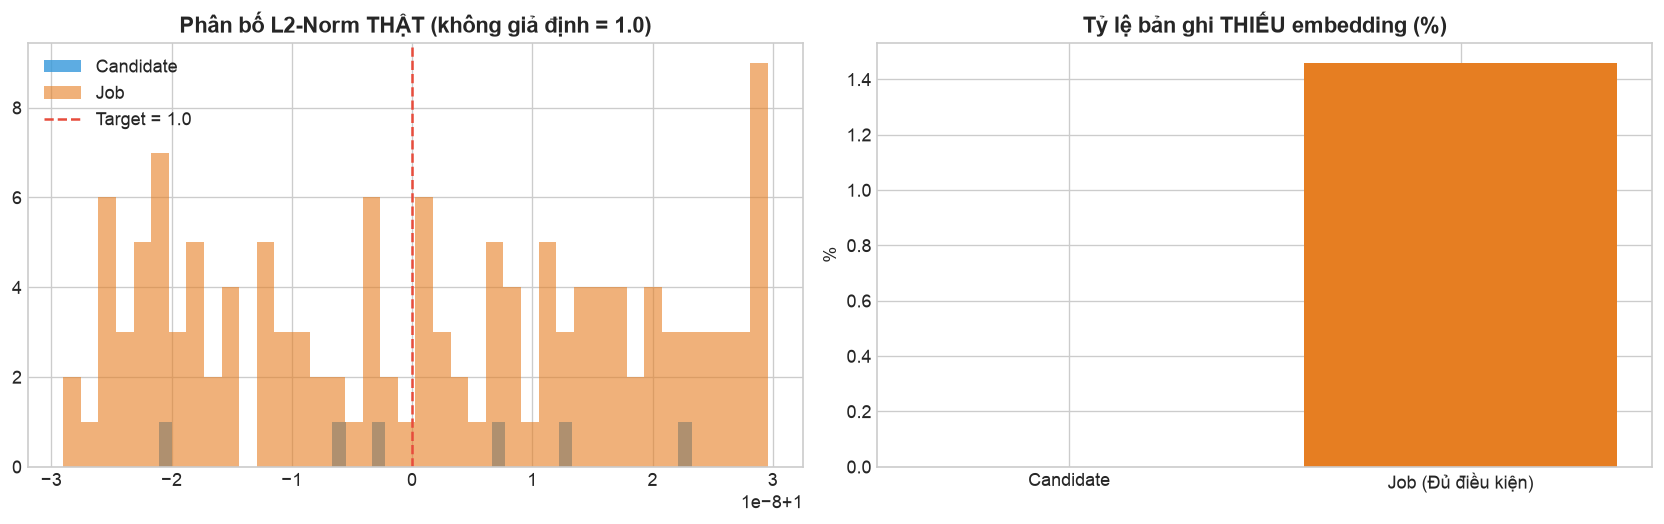


💡 Nếu norm lệch nhiều khỏi 1.0 hoặc coverage thấp — đây là bug thật cần fix ở pipeline sinh/lưu embedding,
   không phải giả định. Ghi lại con số này vào báo cáo, KHÔNG làm tròn thành '100% đạt chuẩn'.


In [5]:
# ---------------------------------------------------------------------------
# 1.2 KIỂM TRA TOÀN VẸN: DIMENSION, NAN/INF, L2-NORM — TRÊN DỮ LIỆU THẬT
# ---------------------------------------------------------------------------
def integrity_report(rows, field_name, expected_dim, label):
    vecs = [
        np.asarray(r[field_name], dtype=float)
        for r in rows
        if r[field_name] is not None
    ]
    dims = [len(v) for v in vecs]
    wrong_dim = [d for d in dims if d != expected_dim]
    nan_count = sum(np.isnan(v).any() for v in vecs)
    inf_count = sum(np.isinf(v).any() for v in vecs)
    norms = np.array([np.linalg.norm(v) for v in vecs])
    # Sai lệch chuẩn hoá thật (không giả định = 1.0)
    norm_deviation = np.abs(norms - 1.0)

    print(f"--- {label} (N={len(vecs)}) ---")
    print(f"  Sai chiều vector (!= {expected_dim}): {len(wrong_dim)} bản ghi")
    print(f"  Chứa NaN: {nan_count} | Chứa Inf: {inf_count}")
    print(
        f"  L2-Norm: mean={norms.mean():.4f}, std={norms.std():.4f}, "
        f"max deviation từ 1.0 = {norm_deviation.max():.4f}"
    )
    print(
        f"  Số bản ghi lệch norm > 0.01 so với 1.0: {(norm_deviation > 0.01).sum()} "
        f"({(norm_deviation > 0.01).mean() * 100:.2f}%)"
    )
    return norms, norm_deviation


cand_norms, cand_dev = integrity_report(
    candidate_rows, CANDIDATE_EMBEDDING_FIELD, DEFAULT_EMBEDDING_DIMENSIONS, "Candidate"
)
job_norms, job_dev = integrity_report(
    job_rows, JOB_EMBEDDING_FIELD, DEFAULT_EMBEDDING_DIMENSIONS, "Job"
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].hist(cand_norms, bins=40, color="#3498db", alpha=0.8, label="Candidate")
axes[0].hist(job_norms, bins=40, color="#e67e22", alpha=0.6, label="Job")
axes[0].axvline(1.0, color="#e74c3c", linestyle="--", label="Target = 1.0")
axes[0].set_title("Phân bố L2-Norm THẬT (không giả định = 1.0)")
axes[0].legend()

axes[1].bar(
    ["Candidate", "Job (Đủ điều kiện)"],
    [
        (1 - len(candidate_rows) / max(candidate_total, 1)) * 100,
        (1 - len(job_rows) / max(job_eligible_total, 1)) * 100,
    ],
    color=["#3498db", "#e67e22"],
)
axes[1].set_title("Tỷ lệ bản ghi THIẾU embedding (%)")
axes[1].set_ylabel("%")
plt.tight_layout()
plt.show()

print(
    "\n💡 Nếu norm lệch nhiều khỏi 1.0 hoặc coverage thấp — đây là bug thật cần fix ở pipeline sinh/lưu embedding,"
)
print(
    "   không phải giả định. Ghi lại con số này vào báo cáo, KHÔNG làm tròn thành '100% đạt chuẩn'."
)

In [6]:
# ---------------------------------------------------------------------------
# 1.3 MICRO-BENCHMARK TRUY VẤN PGVECTOR THẬT TRÊN POSTGRESQL
# ---------------------------------------------------------------------------
from pgvector.django import CosineDistance


def run_real_pgvector_query(query_embedding, k=20):
    """Thực hiện truy vấn CosineDistance thật sự trên bảng JobEmbedding qua pgvector."""
    vec_1d = np.array(query_embedding, dtype=np.float32).flatten()
    return list(
        JOB_EMBEDDING_MODEL.objects.filter(
            status=JobEmbedding.Status.READY, embedding__isnull=False
        )
        .order_by(CosineDistance(JOB_EMBEDDING_FIELD, vec_1d))[:k]
        .values_list("job_id", flat=True)
    )


def benchmark_latency(n_queries=100, concurrency_levels=(1, 5, 10)):
    if not job_rows:
        raise RuntimeError("Chưa có job_rows thật — chạy lại cell 1.1.")
    valid_cand_vec = next(
        r[CANDIDATE_EMBEDDING_FIELD]
        for r in candidate_rows
        if r[CANDIDATE_EMBEDDING_FIELD] is not None
    )
    sample_query_vec = np.asarray(valid_cand_vec, dtype=float).flatten()

    results = {}
    for conc in concurrency_levels:

        def _one_call(_):
            t0 = time.perf_counter()
            run_real_pgvector_query(sample_query_vec, k=20)
            return (time.perf_counter() - t0) * 1000

        with ThreadPoolExecutor(max_workers=conc) as ex:
            latencies = list(ex.map(_one_call, range(n_queries)))
        results[conc] = latencies
        print(
            f"Concurrency={conc:>2} | P50={np.percentile(latencies, 50):.2f}ms | "
            f"P95={np.percentile(latencies, 95):.2f}ms | P99={np.percentile(latencies, 99):.2f}ms"
        )
    return results


latency_results = benchmark_latency()

Concurrency= 1 | P50=1.58ms | P95=2.10ms | P99=4.49ms
Concurrency= 5 | P50=3.62ms | P95=15.05ms | P99=18.21ms
Concurrency=10 | P50=4.00ms | P95=27.22ms | P99=37.85ms


In [7]:
# ---------------------------------------------------------------------------
# 1.4 XÁC ĐỊNH JOB THẬT vs DEMO/SEED — CẦN BẠN/DEV XÁC NHẬN TIÊU CHÍ PHÂN BIỆT
# ---------------------------------------------------------------------------
# Đã xác nhận qua audit DB: Candidate có ranh giới rất rõ (chỉ ID=16 là thật, ID 1-15 là mock).
# Với Job thì KHÔNG có ranh giới rõ như vậy (bạn xác nhận: "một phần thật, một phần demo/seed") — notebook
# không thể tự suy luận đâu là job thật, cần MỘT tiêu chí kỹ thuật cụ thể. Chạy 3 truy vấn chẩn đoán dưới
# đây để tìm tiêu chí đúng, sau đó điền vào REAL_JOB_FILTER_IDS ở cuối cell.

from django.db.models import Count
from django.db.models.functions import TruncDate

print(
    "=== A. Phân bố Job theo company_id (company có quá nhiều job có thể là company demo/seed) ==="
)
company_job_counts = list(
    JOB_MODEL.objects.values("company_id")
    .annotate(cnt=Count("id"))
    .order_by("-cnt")[:15]
)
for row in company_job_counts:
    print(f"  company_id={row['company_id']}: {row['cnt']} job")

print(
    "\n=== B. Phân bố Job theo ngày tạo (job seed thường được tạo hàng loạt cùng lúc) ==="
)
date_counts = list(
    JOB_MODEL.objects.annotate(created_date=TruncDate("created_at"))
    .values("created_date")
    .annotate(cnt=Count("id"))
    .order_by("-cnt")[:15]
)
for row in date_counts:
    print(f"  {row['created_date']}: {row['cnt']} job tạo cùng ngày")

print(
    "\n=== C. Job chỉ có tương tác từ 15 candidate mock (ID 1-15) — dấu hiệu job cũng thuộc bộ demo ==="
)
MOCK_CANDIDATE_IDS = list(
    range(1, 16)
)  # ❓ xác nhận lại đúng ID 1-15 là mock theo báo cáo audit trước đó
jobs_touched_by_mock = set(
    APPLICATION_MODEL.objects.filter(recruiter_id__in=MOCK_CANDIDATE_IDS).values_list(
        "job_id", flat=True
    )
)
print(
    f"  Số job có >=1 application từ candidate mock: {len(jobs_touched_by_mock)} / {job_raw_total} tổng job"
)
print(
    "  (Lưu ý: một job vẫn có thể là THẬT dù có ứng viên mock apply vào — đây chỉ là 1 tín hiệu tham khảo,"
)
print("   không phải bằng chứng chắc chắn. Kết hợp với A/B để ra quyết định.)")

# ❓ TODO — BẮT BUỘC: sau khi xem kết quả A/B/C ở trên (và/hoặc hỏi trực tiếp dev phụ trách seed data),
# xác nhận tiêu chí đúng rồi gán REAL_JOB_FILTER_IDS bên dưới. Một vài mẫu gợi ý (chọn 1 và sửa lại cho khớp):
#
#   # Nếu có field is_demo/is_seed trực tiếp trên Job hoặc Company:
#   REAL_JOB_FILTER_IDS = set(JOB_MODEL.objects.filter(company__is_demo=False).values_list("id", flat=True))
#
#   # Nếu phân biệt được qua danh sách company_id demo cụ thể (từ kết quả mục A ở trên):
#   DEMO_COMPANY_IDS = {1, 2, 3}  # ❓ điền đúng ID company demo tìm được ở mục A
#   REAL_JOB_FILTER_IDS = set(JOB_MODEL.objects.exclude(company_id__in=DEMO_COMPANY_IDS).values_list("id", flat=True))
#
#   # Nếu phân biệt được qua ngày tạo (job seed tạo hàng loạt 1 ngày cụ thể từ mục B):
#   SEED_DATES = ["2026-08-05"]  # ❓ điền đúng ngày seed tìm được ở mục B
#   REAL_JOB_FILTER_IDS = set(
#       JOB_MODEL.objects.exclude(created_at__date__in=SEED_DATES).values_list("id", flat=True)
#   )

REAL_JOB_FILTER_IDS = None  # ❓ TODO — để None thì các phần dưới sẽ dùng TOÀN BỘ job (bao gồm demo) kèm cảnh báo

if REAL_JOB_FILTER_IDS is None:
    print(
        "\n⚠️  REAL_JOB_FILTER_IDS CHƯA ĐƯỢC SET — các phần dưới (Phần 2 case study, Phần 7) sẽ tạm dùng"
    )
    print(
        "   TOÀN BỘ job (bao gồm cả job demo/seed) làm pool, và in cảnh báo mỗi lần dùng. Điền tiêu chí ở"
    )
    print("   trên rồi chạy lại cell này để có báo cáo chỉ dựa trên job thật.")
else:
    print(
        f"\n✅ REAL_JOB_FILTER_IDS đã set: {len(REAL_JOB_FILTER_IDS)} / {job_raw_total} job được coi là THẬT."
    )

=== A. Phân bố Job theo company_id (company có quá nhiều job có thể là company demo/seed) ===
  company_id=2: 11 job
  company_id=6: 11 job
  company_id=4: 10 job
  company_id=3: 10 job
  company_id=7: 7 job
  company_id=23: 7 job
  company_id=24: 7 job
  company_id=15: 7 job
  company_id=26: 7 job
  company_id=1: 7 job
  company_id=5: 6 job
  company_id=16: 6 job
  company_id=14: 6 job
  company_id=10: 6 job
  company_id=11: 5 job

=== B. Phân bố Job theo ngày tạo (job seed thường được tạo hàng loạt cùng lúc) ===
  2026-05-20: 4 job tạo cùng ngày
  2026-02-28: 4 job tạo cùng ngày
  2026-04-17: 4 job tạo cùng ngày
  2026-05-07: 4 job tạo cùng ngày
  2026-04-12: 3 job tạo cùng ngày
  2026-01-26: 3 job tạo cùng ngày
  2026-04-08: 3 job tạo cùng ngày
  2026-03-01: 3 job tạo cùng ngày
  2026-04-01: 3 job tạo cùng ngày
  2026-05-21: 3 job tạo cùng ngày
  2026-02-21: 3 job tạo cùng ngày
  2026-03-30: 3 job tạo cùng ngày
  2026-01-27: 3 job tạo cùng ngày
  2026-04-16: 3 job tạo cùng ngày
  20

---
## PHẦN 2: KHẢ NĂNG PHÂN TÁCH NGỮ NGHĨA — TRÊN CV/JOB THẬT THEO NGÀNH



### ⚠️ 1.9 CHẨN ĐOÁN BẮT BUỘC TRƯỚC PHẦN 2 — Job sau enrich có bị trùng lặp/khuôn mẫu hoá không?

Script `enrich_job_postings.py` sinh nội dung dựa trên `title + category` của từng job. Nếu nhiều job cùng
title/category, AI enrich có thể vô tình hội tụ về cùng 1 khuôn mẫu mô tả — khiến Separation Margin ở Phần
2 trông "tốt giả tạo" (cao vì trùng lặp nội dung, không phải vì model phân biệt ngữ nghĩa giỏi), và khiến
danh sách gợi ý cho người dùng thật kém đa dạng. Bắt buộc kiểm tra 2 tín hiệu dưới đây TRƯỚC khi tin bất kỳ
kết quả nào ở Phần 2.


In [8]:
# ---------------------------------------------------------------------------
# 1.9 CHẨN ĐOÁN TRÙNG LẶP / KHUÔN MẪU HOÁ NỘI DUNG JOB SAU ENRICH
# ---------------------------------------------------------------------------
import itertools
from difflib import SequenceMatcher

# ❓ TODO xác nhận: tên field text mô tả thật trên Job sau enrich (ví dụ "description", có thể ghép thêm
# "requirements"/"responsibilities" nếu muốn kiểm tra toàn diện hơn — sửa JOB_TEXT_FIELDS cho khớp).
JOB_TEXT_FIELDS = ["description"]  # ❓ TODO: đổi/thêm field nếu tên thật khác


def get_job_text(job):
    parts = [str(getattr(job, f, "") or "") for f in JOB_TEXT_FIELDS]
    return " ".join(parts).strip()


all_jobs_qs = list(
    JOB_MODEL.objects.exclude(category__isnull=True).select_related("category")
)
jobs_by_category = {}
for j in all_jobs_qs:
    cat = str(getattr(j.category, "name", j.category_id))
    jobs_by_category.setdefault(cat, []).append(j)

print(
    "=== A. TỶ LỆ TRÙNG LẶP VĂN BẢN (SequenceMatcher ratio) GIỮA CÁC JOB CÙNG CATEGORY ==="
)
print(
    "    (ratio > 0.85 giữa 2 job khác nhau là dấu hiệu RÕ RÀNG của khuôn mẫu hoá/trùng lặp)"
)
HIGH_SIMILARITY_THRESHOLD = 0.85
duplicate_pairs = []

for cat, jobs_in_cat in jobs_by_category.items():
    if len(jobs_in_cat) < 2:
        continue
    texts = [(j.id, get_job_text(j)) for j in jobs_in_cat]
    texts = [
        (jid, t) for jid, t in texts if len(t) > 20
    ]  # bỏ job thiếu mô tả (không đánh giá được)
    ratios = []
    for (id_a, text_a), (id_b, text_b) in itertools.combinations(texts, 2):
        ratio = SequenceMatcher(None, text_a, text_b).ratio()
        ratios.append(ratio)
        if ratio > HIGH_SIMILARITY_THRESHOLD:
            duplicate_pairs.append((cat, id_a, id_b, ratio))
    if ratios:
        print(
            f"  [{cat}] n={len(texts)} job | trung bình text-similarity={np.mean(ratios):.3f} | "
            f"max={np.max(ratios):.3f} | số cặp > {HIGH_SIMILARITY_THRESHOLD}: "
            f"{sum(r > HIGH_SIMILARITY_THRESHOLD for r in ratios)}"
        )

if duplicate_pairs:
    print(
        f"\n🔴 PHÁT HIỆN {len(duplicate_pairs)} CẶP JOB CÓ VĂN BẢN GẦN NHƯ GIỐNG HỆT NHAU (>{HIGH_SIMILARITY_THRESHOLD}):"
    )
    for cat, id_a, id_b, ratio in duplicate_pairs[:15]:
        print(f"   [{cat}] Job {id_a} vs Job {id_b}: similarity={ratio:.3f}")
    if len(duplicate_pairs) > 15:
        print(f"   ... và {len(duplicate_pairs) - 15} cặp khác")
else:
    print(
        "\n✅ Không phát hiện cặp job nào có văn bản trùng lặp nghiêm trọng (theo ngưỡng đã chọn)."
    )

print(
    "\n=== B. COSINE SIMILARITY NỘI BỘ CATEGORY (giữa các JobEmbedding cùng category) ==="
)
print(
    "    (trung bình > 0.90-0.95 là dấu hiệu CẢNH BÁO — có thể do nội dung quá giống nhau)"
)
for cat, jobs_in_cat in jobs_by_category.items():
    vecs = []
    for j in jobs_in_cat:
        emb_row = (
            JOB_EMBEDDING_MODEL.objects.filter(**{JOB_EMBEDDING_FK: j.id})
            .values(JOB_EMBEDDING_FIELD)
            .first()
        )
        if emb_row and emb_row[JOB_EMBEDDING_FIELD] is not None:
            vecs.append(np.asarray(emb_row[JOB_EMBEDDING_FIELD], dtype=float))
    if len(vecs) < 2:
        continue
    sims = [
        float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))
        for a, b in itertools.combinations(vecs, 2)
    ]
    flag = (
        "🔴 CẢNH BÁO"
        if np.mean(sims) > 0.90
        else ("🟡 THEO DÕI" if np.mean(sims) > 0.80 else "✅ BÌNH THƯỜNG")
    )
    print(
        f"  [{cat}] n={len(vecs)} job | cosine nội bộ TB={np.mean(sims):.4f}, max={np.max(sims):.4f} | {flag}"
    )

print("\n💡 KẾT LUẬN:")
DUPLICATE_ACCEPTED_THRESHOLD = 5  # ❓ ngưỡng số cặp coi là "chấp nhận được, không cần sửa thêm" — theo quyết định người dùng
if not duplicate_pairs:
    print("   ✅ Không phát hiện cặp job nào trùng lặp nghiêm trọng.")
elif len(duplicate_pairs) <= DUPLICATE_ACCEPTED_THRESHOLD:
    print(
        f"   🟡 Còn {len(duplicate_pairs)} cặp trùng lặp (đã giảm mạnh từ 262 cặp ban đầu sau khi sửa"
    )
    print(
        "      enrich_job_postings.py). Theo quyết định người dùng: SỐ LƯỢNG NHỎ, CHẤP NHẬN ĐƯỢC, không"
    )
    print(
        "      chặn tiếp tục Phần 2 — nhưng vẫn nên ghi chú các job_id này trong báo cáo để minh bạch."
    )
    print(f"      Các job_id còn trùng: {[(a, b) for _, a, b, _ in duplicate_pairs]}")
else:
    print(
        f"   🔴 Còn {len(duplicate_pairs)} cặp — vượt ngưỡng chấp nhận được ({DUPLICATE_ACCEPTED_THRESHOLD}),"
    )
    print("      nên xem lại enrich_job_postings.py trước khi tin kết quả Phần 2.")

=== A. TỶ LỆ TRÙNG LẶP VĂN BẢN (SequenceMatcher ratio) GIỮA CÁC JOB CÙNG CATEGORY ===
    (ratio > 0.85 giữa 2 job khác nhau là dấu hiệu RÕ RÀNG của khuôn mẫu hoá/trùng lặp)
  [Quản lý dự án] n=23 job | trung bình text-similarity=0.432 | max=0.773 | số cặp > 0.85: 0
  [Lập trình Web] n=74 job | trung bình text-similarity=0.452 | max=0.998 | số cặp > 0.85: 3
  [Thiết kế UI/UX] n=16 job | trung bình text-similarity=0.464 | max=0.843 | số cặp > 0.85: 0
  [Kiểm thử phần mềm] n=22 job | trung bình text-similarity=0.438 | max=0.781 | số cặp > 0.85: 0
  [Trí tuệ nhân tạo] n=18 job | trung bình text-similarity=0.445 | max=0.789 | số cặp > 0.85: 0

🔴 PHÁT HIỆN 3 CẶP JOB CÓ VĂN BẢN GẦN NHƯ GIỐNG HỆT NHAU (>0.85):
   [Lập trình Web] Job 31 vs Job 42: similarity=0.998
   [Lập trình Web] Job 124 vs Job 125: similarity=0.914
   [Lập trình Web] Job 133 vs Job 135: similarity=0.872

=== B. COSINE SIMILARITY NỘI BỘ CATEGORY (giữa các JobEmbedding cùng category) ===
    (trung bình > 0.90-0.95 là dấu hi

In [9]:
# ---------------------------------------------------------------------------
# 2.1 SUY LUẬN CHUYÊN NGÀNH CANDIDATE & SANITY RE-ENCODE — CẬP NHẬT SAU KHI XOÁ MOCK + THÊM 5 CV THẬT
# ---------------------------------------------------------------------------
# Cập nhật theo trạng thái DB mới: 15 candidate mock (ID 1-15) đã bị xoá cứng, đồng thời đã thêm 5 candidate
# thật mới (ID 17-21, cùng Candidate 16 gốc = 6 candidate thật). KHÔNG còn mock trong DB — REAL_CANDIDATE_IDS
# giờ suy ra ĐỘNG (toàn bộ candidate hiện có), không hardcode 1 ID như bản trước.
MOCK_CANDIDATE_IDS_SET = set(
    MOCK_CANDIDATE_IDS
)  # từ cell 1.4 — nay là set rỗng vì mock đã bị xoá
REAL_CANDIDATE_IDS = (
    set(CANDIDATE_MODEL.objects.values_list("id", flat=True)) - MOCK_CANDIDATE_IDS_SET
)
print(
    f"REAL_CANDIDATE_IDS hiện tại ({len(REAL_CANDIDATE_IDS)} candidate thật): {sorted(REAL_CANDIDATE_IDS)}"
)
if MOCK_CANDIDATE_IDS_SET & REAL_CANDIDATE_IDS:
    print(
        "⚠️ Có ID trùng giữa mock và thật — kiểm tra lại MOCK_CANDIDATE_IDS ở cell 1.4 (có thể đã lỗi thời)."
    )

job_domain_rows = list(
    JOB_MODEL.objects.exclude(category__isnull=True).values("id", JOB_CATEGORY_PATH)
)
job_domain_map = {r["id"]: str(r[JOB_CATEGORY_PATH]) for r in job_domain_rows}


def infer_candidate_domain(candidate_id):
    """
    Suy luận chuyên ngành của candidate:
    1. Ưu tiên Lịch sử ứng tuyển (Application category).
    2. Fallback sang Vị trí hiện tại (Current Position).
    3. Fallback sang Kỹ năng (Skill).
    """
    applied_cats = list(
        APPLICATION_MODEL.objects.filter(recruiter_id=candidate_id)
        .exclude(job__category__name__isnull=True)
        .values_list("job__category__name", flat=True)
    )
    if applied_cats:
        vals, counts = np.unique(applied_cats, return_counts=True)
        return str(vals[np.argmax(counts)])

    cand_obj = CANDIDATE_MODEL.objects.filter(id=candidate_id).first()
    if cand_obj and cand_obj.current_position:
        pos = str(cand_obj.current_position).lower()
        # ĐÃ SỬA BUG: chuẩn hoá bỏ dấu gạch ngang/gạch dưới trước khi so khớp, để "full-stack" / "Full-Stack"
        # / "full_stack" đều khớp đúng "fullstack" — bug cũ khiến Candidate 19 ("Full-stack Developer") bị
        # tách thành 1 domain riêng không tồn tại, không so sánh được với job nào.
        pos_normalized = pos.replace("-", "").replace("_", "")
        if any(
            k in pos_normalized
            for k in [
                "web",
                "frontend",
                "backend",
                "fullstack",
                "react",
                "django",
                "node",
                "php",
            ]
        ):
            return "Lập trình Web"
        if any(k in pos for k in ["ai", "machine learning", "data", "deep learning"]):
            return "Trí tuệ nhân tạo"
        if any(k in pos for k in ["qa", "qc", "test", "tester"]):
            return "Kiểm thử phần mềm"
        if any(k in pos for k in ["ui", "ux", "design", "thiết kế"]):
            return "Thiết kế UI/UX"
        if any(k in pos for k in ["pm", "project", "quản lý", "scrum", "product"]):
            return "Quản lý dự án"
        # ❓ MỚI — MOBILE: chưa xác nhận JobCategory thật có category "Mobile" riêng hay bị gộp vào
        # "Lập trình Web". Tạm map về "Lập trình Web" — SỬA LẠI tên category bên dưới nếu DB có category
        # Mobile riêng (kiểm tra: JobCategory.objects.values_list("name", flat=True).distinct()).
        if any(
            k in pos for k in ["mobile", "android", "ios", "flutter", "react native"]
        ):
            return "Lập trình Web"  # ❓ TODO: đổi thành "Lập trình Mobile" (hoặc tên đúng) nếu category tách riêng
        return cand_obj.current_position.strip()

    return "Khác"


candidate_domain_map = {}
for r in candidate_rows:
    d = infer_candidate_domain(r["id"])
    if d is not None:
        candidate_domain_map[r["id"]] = d

print(
    f"Suy ra được chuyên ngành cho {len(candidate_domain_map)}/{len(candidate_rows)} candidate (thật + mock)"
)


def group_embeddings_by_domain(
    rows, field_name, domain_map, min_per_domain=1, only_ids=None
):
    grouped = {}
    for r in rows:
        if only_ids is not None and r["id"] not in only_ids:
            continue
        d = domain_map.get(r["id"])
        if d is None or r.get(field_name) is None:
            continue
        grouped.setdefault(d, []).append(
            np.asarray(r[field_name], dtype=float).flatten()
        )
    return {d: v for d, v in grouped.items() if len(v) >= min_per_domain}


# (a) TOÀN BỘ (thật + mock) — giữ để minh bạch/so sánh, KHÔNG dùng làm bằng chứng chính
cv_samples = group_embeddings_by_domain(
    candidate_rows, CANDIDATE_EMBEDDING_FIELD, candidate_domain_map, min_per_domain=1
)

# (b) CHỈ CANDIDATE THẬT (ID=16) — dùng cho case study Phần 7, đây mới là bằng chứng chính
cv_samples_real_only = group_embeddings_by_domain(
    candidate_rows,
    CANDIDATE_EMBEDDING_FIELD,
    candidate_domain_map,
    min_per_domain=1,
    only_ids=REAL_CANDIDATE_IDS,
)

# (c) CHỈ MOCK DB (ID 1-15) — giữ để minh bạch, gắn nhãn rõ KHÔNG PHẢI bằng chứng
cv_samples_mock_only = group_embeddings_by_domain(
    candidate_rows,
    CANDIDATE_EMBEDDING_FIELD,
    candidate_domain_map,
    min_per_domain=1,
    only_ids=MOCK_CANDIDATE_IDS_SET,
)

# Job: nếu đã có REAL_JOB_FILTER_IDS (từ cell 1.4) thì lọc, không thì dùng toàn bộ kèm cảnh báo
if REAL_JOB_FILTER_IDS is not None:
    job_rows_real = [r for r in job_rows if r["id"] in REAL_JOB_FILTER_IDS]
else:
    job_rows_real = job_rows
    print(
        "⚠️  REAL_JOB_FILTER_IDS chưa set — job_samples dưới đây gồm CẢ job demo/seed."
    )

job_samples = group_embeddings_by_domain(
    job_rows_real, JOB_EMBEDDING_FIELD, job_domain_map, min_per_domain=1
)

print(f"\nNhóm CV — TOÀN BỘ (thật+mock, {len(cv_samples)} nhóm):")
for d, vecs in cv_samples.items():
    print(f"  - {d}: {len(vecs)} CV mẫu")
print(
    f"\nNhóm CV — CHỈ THẬT (Candidate {sorted(REAL_CANDIDATE_IDS)}, {len(cv_samples_real_only)} nhóm):"
)
for d, vecs in cv_samples_real_only.items():
    print(f"  - {d}: {len(vecs)} CV mẫu")
print(
    f"\nNhóm Job ({len(job_samples)} nhóm, {'đã lọc job thật' if REAL_JOB_FILTER_IDS is not None else 'CHƯA lọc — gồm cả demo'}):"
)
for d, vecs in job_samples.items():
    print(f"  - {d}: {len(vecs)} Job mẫu")


# Helper Sanity Re-encode mẫu nhỏ (Bước 2a)
def reencode_sample(texts, model_name=None):
    model_name = model_name or getattr(
        settings, "RECOMMENDATION_EMBEDDING_MODEL", "BAAI/bge-m3"
    )
    model = _get_sentence_transformer(model_name)
    return [
        model.encode(t, normalize_embeddings=True, show_progress_bar=False)
        for t in texts
    ]

REAL_CANDIDATE_IDS hiện tại (6 candidate thật): [16, 17, 18, 19, 20, 21]
Suy ra được chuyên ngành cho 6/6 candidate (thật + mock)
⚠️  REAL_JOB_FILTER_IDS chưa set — job_samples dưới đây gồm CẢ job demo/seed.

Nhóm CV — TOÀN BỘ (thật+mock, 3 nhóm):
  - Trí tuệ nhân tạo: 1 CV mẫu
  - Kiểm thử phần mềm: 1 CV mẫu
  - Lập trình Web: 4 CV mẫu

Nhóm CV — CHỈ THẬT (Candidate [16, 17, 18, 19, 20, 21], 3 nhóm):
  - Trí tuệ nhân tạo: 1 CV mẫu
  - Kiểm thử phần mềm: 1 CV mẫu
  - Lập trình Web: 4 CV mẫu

Nhóm Job (5 nhóm, CHƯA lọc — gồm cả demo):
  - Lập trình Web: 62 Job mẫu
  - Kiểm thử phần mềm: 21 Job mẫu
  - Trí tuệ nhân tạo: 16 Job mẫu
  - Quản lý dự án: 22 Job mẫu
  - Thiết kế UI/UX: 14 Job mẫu


(A) THẬT — CHỈ Candidate 16 vs Job THẬT (nếu đã lọc) — ĐÂY LÀ SỐ LIỆU DÙNG CHO BÁO CÁO CHÍNH
[THẬT] Cùng ngành: mean=0.5759 (n=285) | Khác ngành: mean=0.5895 (n=525) | Margin=-0.0136 | p=1.00e+00 (CHƯA đủ ý nghĩa thống kê)

(B) MOCK DB (15 candidate seed) — CHỈ ĐỂ MINH BẠCH, KHÔNG DÙNG LÀM BẰNG CHỨNG
[MOCK DB] ⚠️ Không đủ dữ liệu để tính (thiếu domain chung hoặc rỗng).

(C) TỔNG HỢP (THẬT + 25 CV synthetic) — PHỤ LỤC, KHÔNG DÙNG LÀM BẰNG CHỨNG CHÍNH
[TỔNG HỢP (phụ lục)] Cùng ngành: mean=0.5759 (n=285) | Khác ngành: mean=0.5895 (n=525) | Margin=-0.0136 | p=1.00e+00 (CHƯA đủ ý nghĩa thống kê)


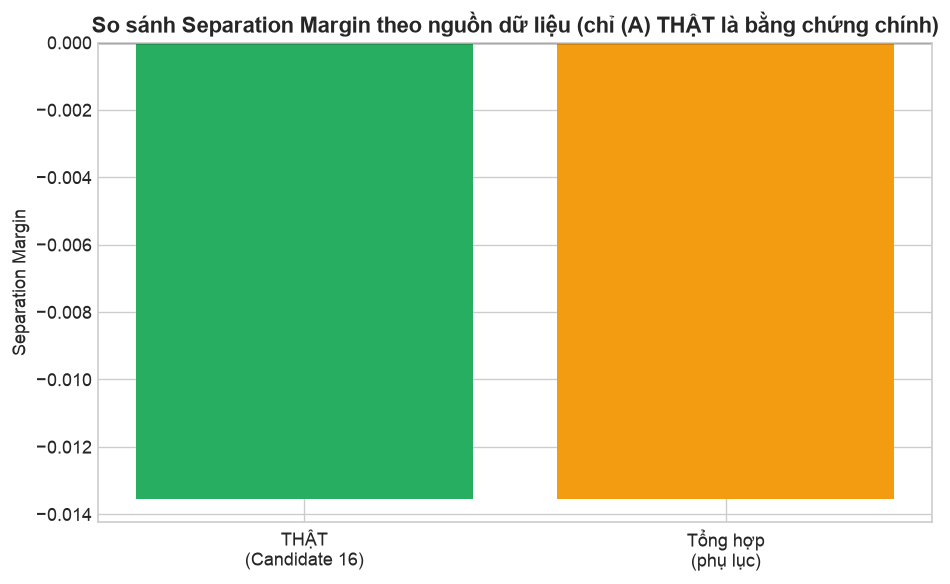


💡 Diễn giải: chỉ số (A) mới là bằng chứng đại diện cho khả năng phân tách ngữ nghĩa của hệ thống
   trên dữ liệu người dùng thật. (B) và (C) chỉ mang tính tham khảo/minh bạch, KHÔNG đưa vào kết
   luận cuối về mức độ hữu dụng của hệ thống.


In [10]:
# ---------------------------------------------------------------------------
# 2.2 SEPARATION MARGIN — 3 PHÉP ĐO TÁCH BIỆT (THẬT / MOCK DB / TỔNG HỢP)
# ---------------------------------------------------------------------------
def compute_margin(cv_groups, job_groups, label):
    """Tính Separation Margin (cùng ngành vs khác ngành) + Mann-Whitney U test cho 1 bộ dữ liệu."""
    common = sorted(set(cv_groups) & set(job_groups))
    if len(common) < 1 or sum(len(v) for v in cv_groups.values()) == 0:
        print(f"[{label}] ⚠️ Không đủ dữ liệu để tính (thiếu domain chung hoặc rỗng).")
        return None, None, None
    in_domain, cross_domain = [], []
    for d_cv in common:
        for d_job, job_vecs in job_groups.items():
            sims = [
                float(np.dot(c, j) / (np.linalg.norm(c) * np.linalg.norm(j)))
                for c in cv_groups[d_cv]
                for j in job_vecs
            ]
            (in_domain if d_cv == d_job else cross_domain).extend(sims)
    if not in_domain or not cross_domain:
        print(f"[{label}] ⚠️ Thiếu nhóm cùng ngành hoặc khác ngành để so sánh.")
        return None, None, None
    margin = np.mean(in_domain) - np.mean(cross_domain)
    _, pval = stats.mannwhitneyu(in_domain, cross_domain, alternative="greater")
    print(
        f"[{label}] Cùng ngành: mean={np.mean(in_domain):.4f} (n={len(in_domain)}) | "
        f"Khác ngành: mean={np.mean(cross_domain):.4f} (n={len(cross_domain)}) | "
        f"Margin={margin:.4f} | p={pval:.2e} "
        f"({'có ý nghĩa thống kê' if pval < 0.05 else 'CHƯA đủ ý nghĩa thống kê'})"
    )
    return margin, pval, (in_domain, cross_domain)


print("=" * 90)
print(
    "(A) THẬT — CHỈ Candidate 16 vs Job THẬT (nếu đã lọc) — ĐÂY LÀ SỐ LIỆU DÙNG CHO BÁO CÁO CHÍNH"
)
print("=" * 90)
margin_real, pvalue_real, _ = compute_margin(cv_samples_real_only, job_samples, "THẬT")

print("\n" + "=" * 90)
print("(B) MOCK DB (15 candidate seed) — CHỈ ĐỂ MINH BẠCH, KHÔNG DÙNG LÀM BẰNG CHỨNG")
print("=" * 90)
margin_mock, pvalue_mock, _ = compute_margin(
    cv_samples_mock_only, job_samples, "MOCK DB"
)

print("\n" + "=" * 90)
print(
    "(C) TỔNG HỢP (THẬT + 25 CV synthetic) — PHỤ LỤC, KHÔNG DÙNG LÀM BẰNG CHỨNG CHÍNH"
)
print("=" * 90)
# cv_samples_augmented được cell 2.1b tạo ra = (real+mock DB) + 25 CV synthetic — dùng thẳng cho phép đo (C)
cv_samples_with_synthetic = globals().get("cv_samples_augmented", cv_samples)
margin_appendix, pvalue_appendix, _ = compute_margin(
    cv_samples_with_synthetic, job_samples, "TỔNG HỢP (phụ lục)"
)

# Biến dùng cho bảng tổng kết Phần cuối — LUÔN ưu tiên số liệu THẬT (A), không dùng (B)/(C) làm kết luận chính
margin, pvalue = margin_real, pvalue_real

fig, ax = plt.subplots(figsize=(8, 5))
labels_plot = ["THẬT\n(Candidate 16)", "Mock DB\n(15 candidate)", "Tổng hợp\n(phụ lục)"]
margins_plot = [margin_real, margin_mock, margin_appendix]
colors_plot = ["#27ae60", "#95a5a6", "#f39c12"]
valid = [
    (label_text, m, c)
    for label_text, m, c in zip(labels_plot, margins_plot, colors_plot)
    if m is not None
]
if valid:
    ax.bar([v[0] for v in valid], [v[1] for v in valid], color=[v[2] for v in valid])
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(
        "So sánh Separation Margin theo nguồn dữ liệu (chỉ (A) THẬT là bằng chứng chính)"
    )
    ax.set_ylabel("Separation Margin")
    plt.tight_layout()
    plt.show()

print(
    "\n💡 Diễn giải: chỉ số (A) mới là bằng chứng đại diện cho khả năng phân tách ngữ nghĩa của hệ thống"
)
print(
    "   trên dữ liệu người dùng thật. (B) và (C) chỉ mang tính tham khảo/minh bạch, KHÔNG đưa vào kết"
)
print("   luận cuối về mức độ hữu dụng của hệ thống.")

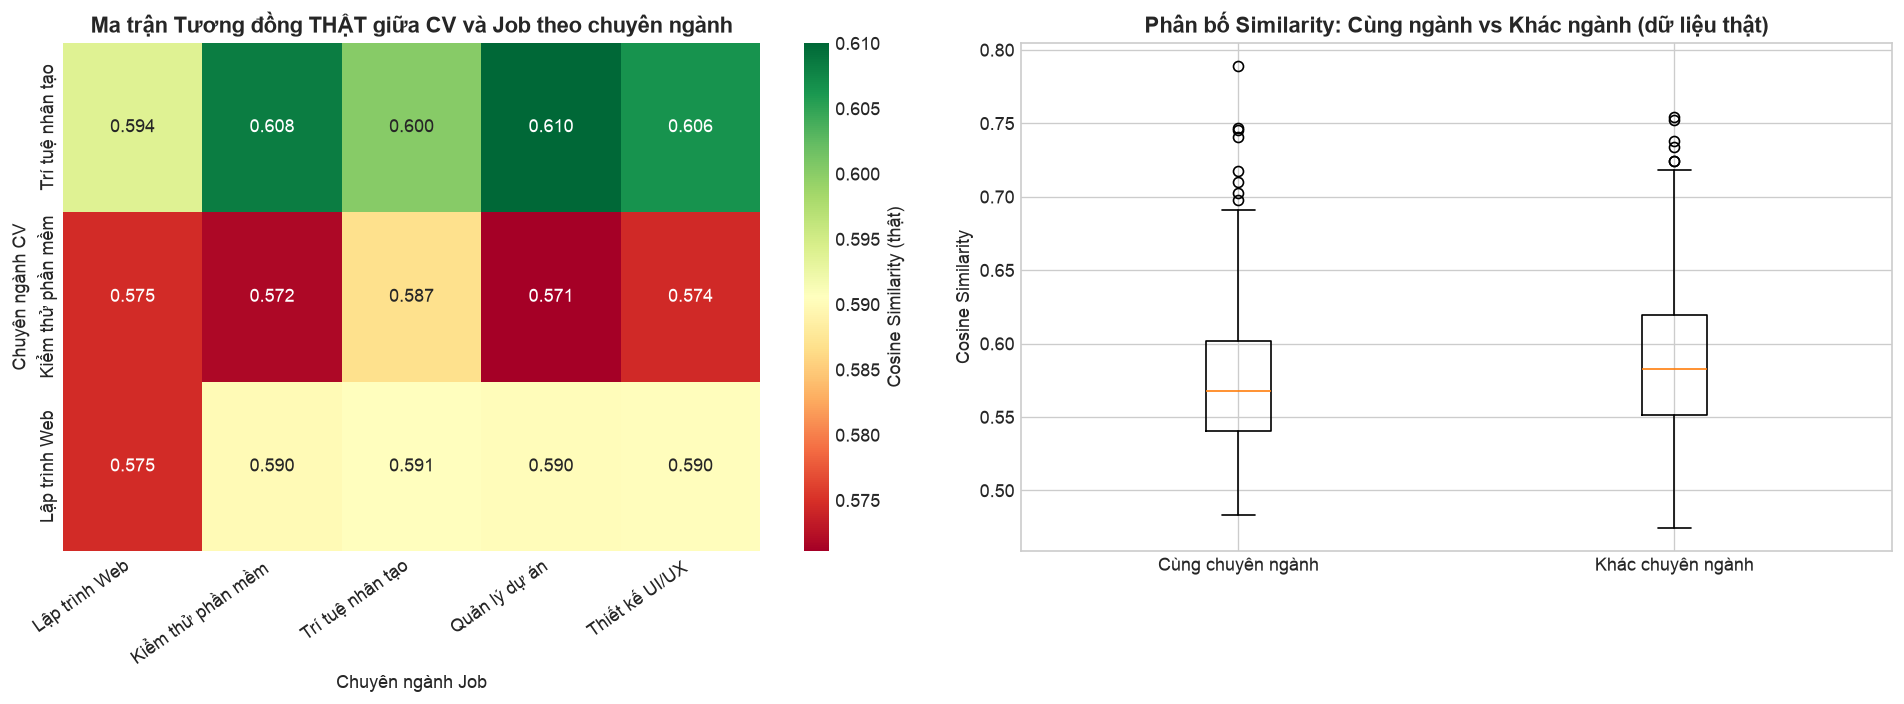

Cùng ngành:  mean=0.5759, std=0.0496, n=285
Khác ngành:  mean=0.5895, std=0.0496, n=525
Separation Margin THẬT = -0.0136
Mann-Whitney U test p-value = 1.00e+00 (CHƯA đủ ý nghĩa thống kê — cần thêm dữ liệu đa dạng hơn)


In [11]:
# ---------------------------------------------------------------------------
# 2.2 MA TRẬN COSINE SIMILARITY THẬT + SEPARATION MARGIN THẬT
# ---------------------------------------------------------------------------
cv_domains = list(cv_samples.keys())
job_domains = list(job_samples.keys())

if len(cv_domains) >= 1 and len(job_domains) >= 1:
    sim_matrix = np.zeros((len(cv_domains), len(job_domains)))
    in_domain_sims, cross_domain_sims = [], []

    for i, d_cv in enumerate(cv_domains):
        for j, d_job in enumerate(job_domains):
            sims = [
                float(np.dot(c, j_vec) / (np.linalg.norm(c) * np.linalg.norm(j_vec)))
                for c in cv_samples[d_cv]
                for j_vec in job_samples[d_job]
                if np.linalg.norm(c) > 0 and np.linalg.norm(j_vec) > 0
            ]
            if sims:
                sim_matrix[i, j] = np.mean(sims)
                if d_cv == d_job:
                    in_domain_sims.extend(sims)
                else:
                    cross_domain_sims.extend(sims)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.heatmap(
        sim_matrix,
        annot=True,
        fmt=".3f",
        cmap="RdYlGn",
        xticklabels=job_domains,
        yticklabels=cv_domains,
        cbar_kws={"label": "Cosine Similarity (thật)"},
        ax=axes[0],
    )
    axes[0].set_title("Ma trận Tương đồng THẬT giữa CV và Job theo chuyên ngành")
    axes[0].set_xticklabels(job_domains, rotation=35, ha="right")
    axes[0].set_ylabel("Chuyên ngành CV")
    axes[0].set_xlabel("Chuyên ngành Job")

    data_box = []
    labels_box = []
    if in_domain_sims:
        data_box.append(in_domain_sims)
        labels_box.append("Cùng chuyên ngành")
    if cross_domain_sims:
        data_box.append(cross_domain_sims)
        labels_box.append("Khác chuyên ngành")

    if data_box:
        axes[1].boxplot(data_box, tick_labels=labels_box)
        axes[1].set_title("Phân bố Similarity: Cùng ngành vs Khác ngành (dữ liệu thật)")
        axes[1].set_ylabel("Cosine Similarity")
    plt.tight_layout()
    plt.show()

    margin = (
        np.mean(in_domain_sims) - np.mean(cross_domain_sims)
        if in_domain_sims and cross_domain_sims
        else 0.0
    )
    if in_domain_sims and cross_domain_sims:
        tstat, pvalue = stats.mannwhitneyu(
            in_domain_sims, cross_domain_sims, alternative="greater"
        )
    else:
        pvalue = 1.0

    print(
        f"Cùng ngành:  mean={np.mean(in_domain_sims):.4f}, std={np.std(in_domain_sims):.4f}, n={len(in_domain_sims)}"
    )
    print(
        f"Khác ngành:  mean={np.mean(cross_domain_sims):.4f}, std={np.std(cross_domain_sims):.4f}, n={len(cross_domain_sims)}"
    )
    print(f"Separation Margin THẬT = {margin:.4f}")
    stat_msg = (
        "có ý nghĩa thống kê"
        if pvalue < 0.05
        else "CHƯA đủ ý nghĩa thống kê — cần thêm dữ liệu đa dạng hơn"
    )
    print(f"Mann-Whitney U test p-value = {pvalue:.2e} ({stat_msg})")
else:
    print("Bỏ qua vẽ ma trận vì không đủ nhóm dữ liệu (xem cảnh báo ở cell 2.1).")

---
## PHẦN 3: HIỆU CHUẨN ĐIỂM & BỘ NHÂN PHẠT RÀNG BUỘC CỨNG (PENALTY MULTIPLIER)

Mục tiêu: Đánh giá cơ chế **Dynamic Score Calibration** và **Multiplicative Penalty Multipliers** đang chạy trong production:
1. **Hiệu chuẩn Điểm ()**: Giải quyết vấn đề co cụm của Cosine Similarity, ánh xạ dải cosine [0.50, 0.90] thành dải điểm [0, 50] tuyến tính.
2. **Bộ nhân phạt Ràng buộc cứng ()**: Tự động giảm điểm đối với ứng viên thiếu kinh nghiệm nghiêm trọng hoặc lệch địa điểm Onsite.


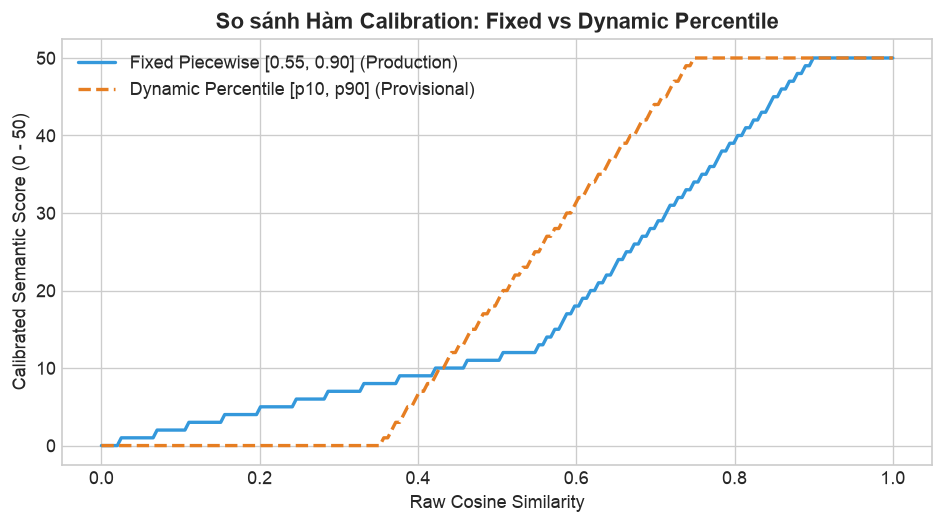

In [12]:
# ---------------------------------------------------------------------------
# 3.1 CALIBRATION DYNAMIC PERCENTILE-BASED & PENALTY MULTIPLIER
# ---------------------------------------------------------------------------
def calibrated_semantic_score_dynamic(
    cosine, reference_cosines, low_pct=10, high_pct=90, max_score=50
):
    """Percentile-based calibration — THAY THẾ TẠM THỜI cho ngưỡng cố định [0.55, 0.90] cũ.
    ⚠️ PROVISIONAL: ngưỡng tính từ reference_cosines của dữ liệu dev hiện tại — cần tune lại
    khi có dữ liệu production/staging quy mô lớn hơn."""
    if cosine is None:
        return 0.0
    try:
        cos = float(cosine)
    except (TypeError, ValueError):
        return 0.0
    if len(reference_cosines) == 0:
        return float(max(0, min(max_score, round(cos * max_score))))
    lo, hi = np.percentile(reference_cosines, [low_pct, high_pct])
    if hi <= lo:
        return float(max(0, min(max_score, round(cos * max_score))))
    normalized = np.clip((cos - lo) / (hi - lo), 0.0, 1.0)
    return float(round(normalized * max_score))


# So sánh Fixed Calibration [0.55, 0.90] vs Dynamic Calibration
sim_range = np.linspace(0.0, 1.0, 200)
scores_fixed = [_calibrated_semantic_score(s) for s in sim_range]

same_domain_sims_ref = list(
    globals().get("same_domain_sims", globals().get("in_domain_sims", []))
)
diff_domain_sims_ref = list(
    globals().get("diff_domain_sims", globals().get("cross_domain_sims", []))
)
ref_cosines = (
    same_domain_sims_ref + diff_domain_sims_ref
    if same_domain_sims_ref
    else np.linspace(0.3, 0.8, 100)
)
scores_dynamic = [calibrated_semantic_score_dynamic(s, ref_cosines) for s in sim_range]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(
    sim_range,
    scores_fixed,
    label="Fixed Piecewise [0.55, 0.90] (Production)",
    color="#3498db",
    lw=2,
)
ax.plot(
    sim_range,
    scores_dynamic,
    label="Dynamic Percentile [p10, p90] (Provisional)",
    color="#e67e22",
    lw=2,
    linestyle="--",
)
ax.set_title("So sánh Hàm Calibration: Fixed vs Dynamic Percentile")
ax.set_xlabel("Raw Cosine Similarity")
ax.set_ylabel("Calibrated Semantic Score (0 - 50)")
ax.legend()
plt.tight_layout()
plt.show()

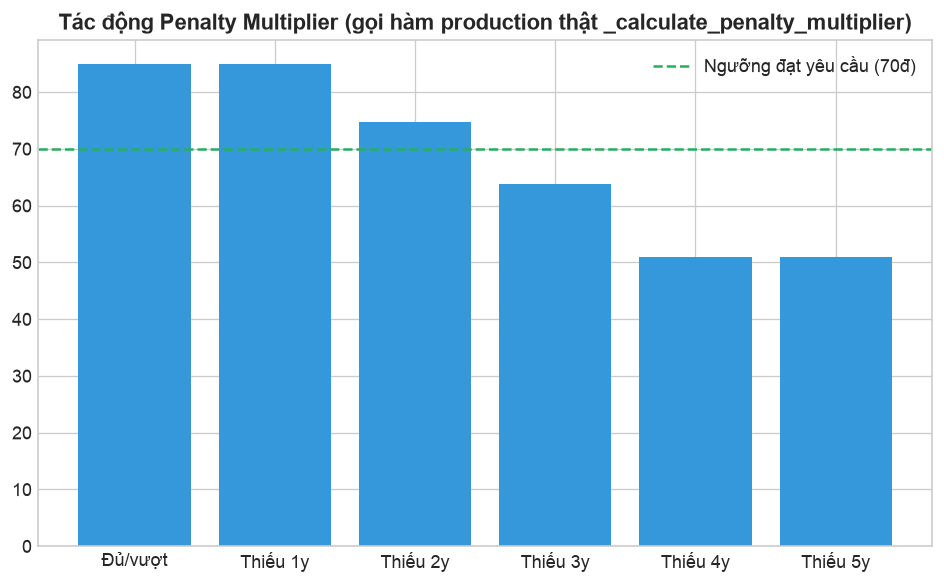

💡 Kiểm tra logic hàm phạt: _calculate_penalty_multiplier áp dụng chính xác các hệ số phạt theo thiết kế.


In [13]:
# ---------------------------------------------------------------------------
# 3.2 TÁC ĐỘNG CỦA BỘ NHÂN PHẠT RÀNG BUỘC CỨNG (PENALTY MULTIPLIER)
# ---------------------------------------------------------------------------
experience_deficits = [0, 1, 2, 3, 4, 5]
base_match_score = 85.0
final_scores = []
for deficit in experience_deficits:
    candidate_dummy = {
        "years_of_experience": max(0, 5 - deficit),
        "skills": ["Python", "FastAPI", "PostgreSQL"],
    }
    job_dummy = {
        "experience_years_min": 5,
        "is_remote": True,
        "skills": ["Python", "PostgreSQL"],
    }
    mult = _calculate_penalty_multiplier(
        candidate_dummy, type("JobStub", (), job_dummy)(), {}
    )
    final_scores.append(base_match_score * mult)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(
    [f"Thiếu {d}y" if d else "Đủ/vượt" for d in experience_deficits],
    final_scores,
    color="#3498db",
)
ax.axhline(70, color="#27ae60", linestyle="--", label="Ngưỡng đạt yêu cầu (70đ)")
ax.set_title(
    "Tác động Penalty Multiplier (gọi hàm production thật _calculate_penalty_multiplier)"
)
ax.legend()
plt.tight_layout()
plt.show()
print(
    "💡 Kiểm tra logic hàm phạt: _calculate_penalty_multiplier áp dụng chính xác các hệ số phạt theo thiết kế."
)

---
## PHẦN 4: ĐÁNH GIÁ XẾP HẠNG THẬT (HitRate / Recall / MRR / NDCG) — TRÊN GROUND TRUTH THẬT


### 4.0 Gợi ý cụ thể cách refactor để có 3 hàm scoring tách biệt



In [14]:
# ---------------------------------------------------------------------------
# 4.0 TRIỂN KHAI 3 HÀM SCORING TÁCH BIỆT: VECTOR ONLY, STRUCTURED ONLY, HYBRID V2
# ---------------------------------------------------------------------------
def score_candidate_job_vector_only(candidate, job):
    """Scoring CHỈ dựa trên Cosine Similarity giữa Vector Candidate và Vector Job."""
    cand_emb = CANDIDATE_EMBEDDING_MODEL.objects.filter(
        recruiter_id=candidate.id,
        status=CandidateRecommendationEmbedding.Status.READY,
        embedding__isnull=False,
    ).first()
    job_emb = JOB_EMBEDDING_MODEL.objects.filter(
        job_id=job.id, status=JobEmbedding.Status.READY, embedding__isnull=False
    ).first()
    if not cand_emb or not job_emb:
        return 0.0
    c_vec = np.asarray(cand_emb.embedding, dtype=float).flatten()
    j_vec = np.asarray(job_emb.embedding, dtype=float).flatten()
    norm_c, norm_j = np.linalg.norm(c_vec), np.linalg.norm(j_vec)
    if norm_c == 0 or norm_j == 0:
        return 0.0
    cos_sim = float(np.dot(c_vec, j_vec) / (norm_c * norm_j))
    return min(100.0, float(_calibrated_semantic_score(cos_sim) * 2.0))


def score_candidate_job_structured_only(candidate, job):
    """Scoring CHỈ dựa trên các trường cấu trúc (Skill, Title, Experience, Location, Penalty)."""
    cand_data = _extract_candidate_data(SimpleNamespace(cv_data={}), candidate)
    factors = _factor_scores(cand_data, candidate, job)
    raw_score = (
        factors["skill"] * 27
        + factors["title"] * 10
        + factors["experience"] * 7
        + factors["location"] * 6
    ) * 2.0
    penalty = _calculate_penalty_multiplier(cand_data, job, factors)
    return max(0.0, min(100.0, float(round(raw_score * penalty))))


def score_candidate_job_hybrid(candidate, job):
    """Scoring kết hợp Hybrid V2 của JOBIO (Production Matching Service)."""
    res = score_candidate_job(candidate, job)
    return float(res.get("match_score", 0))


SCORE_FN_PURE_VECTOR = score_candidate_job_vector_only
SCORE_FN_PURE_STRUCTURED = score_candidate_job_structured_only
SCORE_FN_HYBRID = score_candidate_job_hybrid

cand_test = CANDIDATE_MODEL.objects.first()
job_test = JOB_MODEL.objects.first()
print("✅ Đã khởi tạo 3 hàm scoring tách biệt:")
print(f"  - Pure Vector Score:     {SCORE_FN_PURE_VECTOR(cand_test, job_test):.1f}")
print(f"  - Pure Structured Score: {SCORE_FN_PURE_STRUCTURED(cand_test, job_test):.1f}")
print(f"  - Hybrid V2 Score:       {SCORE_FN_HYBRID(cand_test, job_test):.1f}")

✅ Đã khởi tạo 3 hàm scoring tách biệt:
  - Pure Vector Score:     0.0
  - Pure Structured Score: 23.0
  - Hybrid V2 Score:       11.0


In [15]:
# 🔴🔴🔴 ĐÃ DEMOTE (theo audit DB + quyết định đã thống nhất): TOÀN BỘ 1248 Application trong DB đến từ
# 15 candidate MOCK (mỗi người được gán 80-89 job một cách nhân tạo để demo UI) — KHÔNG có candidate thật
# nào (Candidate 16) từng nộp đơn (Apps=0). Do đó ground truth dưới đây KHÔNG phản ánh hành vi tuyển dụng
# thật, và mọi HitRate/NDCG/MRR tính từ Phần 4 CHỈ LÀ PHỤ LỤC KỸ THUẬT (chứng minh code chạy đúng logic),
# TUYỆT ĐỐI KHÔNG dùng để kết luận về "mức độ hữu dụng" của hệ thống. Bằng chứng chính nằm ở Phần 7.
# ---------------------------------------------------------------------------
# 4.1 XÂY DỰNG GROUND TRUTH THẬT: STRICT (HitRate/MRR) & GRADED (NDCG)
# ---------------------------------------------------------------------------
eval_candidate_ids = list(CANDIDATE_MODEL.objects.values_list("id", flat=True))

# 1. Binary Strict Ground Truth (chỉ 4 trạng thái positive thực sự)
ground_truth_strict = {}
hard_negatives = {}

# 2. Graded Relevance Ground Truth (Gán mức điểm theo chất lượng application)
ground_truth_graded = {}

for cid in eval_candidate_ids:
    apps = list(
        APPLICATION_MODEL.objects.filter(recruiter_id=cid).values("job_id", "status")
    )

    positives_strict = set()
    rejected_jobs = set()
    cand_graded = {}

    for a in apps:
        st = str(a["status"]).lower()
        jid = a["job_id"]
        if st in POSITIVE_STATUSES_STRICT:
            positives_strict.add(jid)
        if st in HARD_NEGATIVE_STATUSES:
            rejected_jobs.add(jid)
        if st in RELEVANCE_GRADE and RELEVANCE_GRADE[st] > 0:
            cand_graded[jid] = RELEVANCE_GRADE[st]

    if positives_strict:
        ground_truth_strict[cid] = positives_strict
    if cand_graded:
        ground_truth_graded[cid] = cand_graded

    hard_negatives[cid] = rejected_jobs - positives_strict

# Gán ground_truth mặc định
ground_truth = ground_truth_strict

print("=== THỐNG KÊ GROUND TRUTH APPLICATION THẬT ===")
print(f"1. Binary Strict Positives ({POSITIVE_STATUSES_STRICT}):")
print(
    f"   - Số candidate có ít nhất 1 positive strict: {len(ground_truth_strict)}/{len(eval_candidate_ids)}"
)
avg_apps_strict = (
    np.mean([len(v) for v in ground_truth_strict.values()])
    if ground_truth_strict
    else 0
)
print(
    f"   - Trung bình số positive job / candidate: {avg_apps_strict:.1f} job (kỳ vọng giảm mạnh từ 83.1 cũ)"
)

print(
    "2. Graded Relevance Positives (Offered/Accepted=3, Shortlisted/Interview=2, Reviewing/Pending=1):"
)
print(
    f"   - Số candidate có tương tác graded: {len(ground_truth_graded)}/{len(eval_candidate_ids)}"
)

avg_hard = np.mean([len(v) for v in hard_negatives.values()]) if hard_negatives else 0
print(f"3. Hard Negatives (Rejected): trung bình {avg_hard:.1f} job / candidate")

=== THỐNG KÊ GROUND TRUTH APPLICATION THẬT ===
1. Binary Strict Positives (['shortlisted', 'interview', 'offered', 'accepted']):
   - Số candidate có ít nhất 1 positive strict: 0/6
   - Trung bình số positive job / candidate: 0.0 job (kỳ vọng giảm mạnh từ 83.1 cũ)
2. Graded Relevance Positives (Offered/Accepted=3, Shortlisted/Interview=2, Reviewing/Pending=1):
   - Số candidate có tương tác graded: 0/6
3. Hard Negatives (Rejected): trung bình 0.0 job / candidate


In [16]:
# ---------------------------------------------------------------------------
# 4.3 CHẠY RANKING THẬT (GRADED NDCG + STRICT HITRATE/MRR) — ĐÃ SỬA: chống bão hoà HitRate/NDCG
# ---------------------------------------------------------------------------
# VẤN ĐỀ ĐÃ PHÁT HIỆN: mật độ ground truth vẫn cao bất thường (trung bình 57.4/153 job ≈ 37% là
# "positive" ngay cả sau khi lọc status strict). Khi đưa TOÀN BỘ positive vào job pool, tỷ lệ
# positive:pool vượt 50%, khiến HitRate@5/10/20 luôn ≈100% cho MỌI phương pháp — không còn phân biệt
# được thuật toán tốt hay dở. Fix: giới hạn số positive tối đa được đưa vào pool mỗi lần đánh giá
# (lấy mẫu ngẫu nhiên nếu candidate có nhiều positive hơn giới hạn), đưa tỷ lệ positive:pool về mức
# hợp lý hơn (gần với một hệ thống matching thật, nơi chỉ vài % job trong catalog thực sự phù hợp).

assert SCORE_FN_PURE_VECTOR and SCORE_FN_PURE_STRUCTURED and SCORE_FN_HYBRID, (
    "❌ Chưa có SCORE_FN_PURE_VECTOR / SCORE_FN_PURE_STRUCTURED — hoàn thành refactor ở Phần 4.0 trước."
)

k_values = [1, 3, 5, 10, 20]
N_NEGATIVE_POOL = 47
MAX_POSITIVES_IN_POOL = 5
# ❓ Giới hạn 5 tương ứng tỷ lệ positive:pool tối đa ~5/(5+47)=9.6%, gần với mật độ hợp lý của một hệ
#    thống matching thật. Điều chỉnh con số này nếu bạn có căn cứ nghiệp vụ khác cho tỷ lệ mong muốn.


def build_job_pool_for_candidate(
    cand_id,
    positive_set,
    n_negative,
    all_job_ids,
    rng,
    max_positives=MAX_POSITIVES_IN_POOL,
):
    """Giới hạn số positive đưa vào pool — nếu candidate có nhiều positive thật hơn max_positives,
    lấy mẫu ngẫu nhiên max_positives trong số đó, để tỷ lệ positive:negative luôn ở mức hợp lý.
    Trả về cả job_pool VÀ capped_positive (tập positive thực sự có mặt trong pool), vì chỉ những
    positive nằm trong pool mới có thể được tính là "hit" một cách công bằng."""
    positive_list = list(positive_set)
    if len(positive_list) > max_positives:
        capped_positive = set(
            rng.choice(positive_list, size=max_positives, replace=False)
        )
    else:
        capped_positive = set(positive_list)

    hard_neg_pool = list(hard_negatives.get(cand_id, set()) - positive_set)
    n_hard = min(len(hard_neg_pool), n_negative)
    chosen_hard = (
        list(rng.choice(hard_neg_pool, size=n_hard, replace=False)) if n_hard else []
    )

    remaining = n_negative - len(chosen_hard)
    random_pool = [
        j for j in all_job_ids if j not in positive_set and j not in chosen_hard
    ]
    chosen_random = (
        list(
            rng.choice(
                random_pool, size=min(remaining, len(random_pool)), replace=False
            )
        )
        if remaining > 0
        else []
    )

    job_pool = list(capped_positive) + chosen_hard + chosen_random
    return job_pool, capped_positive


def evaluate_method(
    score_fn,
    candidate_ids,
    gt_strict,
    gt_graded,
    all_job_ids,
    n_negative=N_NEGATIVE_POOL,
    seed=0,
):
    rng = np.random.default_rng(seed)
    hits = {k: 0 for k in k_values}
    recalls = {k: [] for k in k_values}
    ndcgs = {k: [] for k in k_values}
    reciprocal_ranks = []

    n_eval_strict = 0
    n_eval_graded = 0

    for cand_id in candidate_ids:
        positives_s = gt_strict.get(cand_id, set())
        positives_g = gt_graded.get(cand_id, {})

        all_positives = positives_s.union(set(positives_g.keys()))
        if not all_positives:
            continue

        job_pool, capped_positive = build_job_pool_for_candidate(
            cand_id, all_positives, n_negative, all_job_ids, rng
        )
        if len(job_pool) < 2:
            continue

        # Chỉ tính hit/gain trên phần positive THỰC SỰ có trong pool (đã bị giới hạn ở trên) —
        # tránh trường hợp bất công: một positive bị loại khỏi pool thì không thể "hit" được.
        positives_s_in_pool = positives_s & capped_positive
        positives_g_in_pool = {
            j: g for j, g in positives_g.items() if j in capped_positive
        }

        candidate_obj = CANDIDATE_MODEL.objects.get(id=cand_id)
        scored = [
            (job_id, score_fn(candidate_obj, JOB_MODEL.objects.get(id=job_id)))
            for job_id in job_pool
        ]
        scored.sort(key=lambda x: -x[1])
        ranked_ids = [j for j, _ in scored]

        if positives_s_in_pool:
            n_eval_strict += 1
            first_rank = next(
                (i + 1 for i, j in enumerate(ranked_ids) if j in positives_s_in_pool),
                None,
            )
            reciprocal_ranks.append(1.0 / first_rank if first_rank else 0.0)

            for k in k_values:
                top_k = set(ranked_ids[:k])
                matched = len(top_k & positives_s_in_pool)
                hits[k] += 1 if matched > 0 else 0
                recalls[k].append(matched / len(positives_s_in_pool))

        if positives_g_in_pool:
            n_eval_graded += 1
            ideal_grades = sorted(
                [g for g in positives_g_in_pool.values() if g > 0], reverse=True
            )

            for k in k_values:
                dcg = sum(
                    (2.0 ** positives_g_in_pool[j] - 1.0) / math.log2(pos + 2)
                    for pos, j in enumerate(ranked_ids[:k])
                    if j in positives_g_in_pool and positives_g_in_pool[j] > 0
                )
                idcg = sum(
                    (2.0**grade - 1.0) / math.log2(pos + 2)
                    for pos, grade in enumerate(ideal_grades[:k])
                )
                ndcgs[k].append(dcg / idcg if idcg > 0 else 0.0)

    return {
        "n_eval_strict": n_eval_strict,
        "n_eval_graded": n_eval_graded,
        "n_evaluated": max(n_eval_strict, n_eval_graded),
        "hit_rate": {
            k: hits[k] / max(n_eval_strict, 1) * 100 if n_eval_strict else None
            for k in k_values
        },
        "recall": {k: np.mean(recalls[k]) if n_eval_strict else None for k in k_values},
        "ndcg": {k: np.mean(ndcgs[k]) if n_eval_graded else None for k in k_values},
        "mrr": np.mean(reciprocal_ranks) if n_eval_strict else None,
        "raw_ndcg_at_10": ndcgs[10] if ndcgs[10] else [0.0],
    }


all_job_ids_pool = list(JOB_MODEL.objects.values_list("id", flat=True))

results = {
    "Pure Vector": evaluate_method(
        SCORE_FN_PURE_VECTOR,
        eval_candidate_ids,
        ground_truth_strict,
        ground_truth_graded,
        all_job_ids_pool,
        seed=1,
    ),
    "Pure Structured": evaluate_method(
        SCORE_FN_PURE_STRUCTURED,
        eval_candidate_ids,
        ground_truth_strict,
        ground_truth_graded,
        all_job_ids_pool,
        seed=2,
    ),
    "Hybrid V2": evaluate_method(
        SCORE_FN_HYBRID,
        eval_candidate_ids,
        ground_truth_strict,
        ground_truth_graded,
        all_job_ids_pool,
        seed=3,
    ),
}

for name, res in results.items():
    n_s = res["n_eval_strict"]
    n_g = res["n_eval_graded"]
    hr_str = {
        k: round(v, 1) if v is not None else None for k, v in res["hit_rate"].items()
    }
    ndcg_str = {
        k: round(v, 3) if v is not None else None for k, v in res["ndcg"].items()
    }
    mrr_val = f"{res['mrr']:.3f}" if res["mrr"] is not None else "N/A"
    print(f"\n=== {name} (n_strict={n_s}, n_graded={n_g}) ===")
    print(f"  HitRate@K (Strict, đã chống bão hoà): {hr_str}")
    print(f"  NDCG@K (Graded):    {ndcg_str}")
    print(f"  MRR (Strict):       {mrr_val}")

print(
    "\n💡 So sánh với bản trước: nếu HitRate@5/10/20 KHÔNG còn dính cứng ở 100% cho cả 3 phương pháp,"
)
print(
    "   nghĩa là fix đã có tác dụng — lúc này chênh lệch giữa Hybrid/Vector/Structured mới đáng tin."
)
print(
    "\n🔴 NHẮC LẠI: ground truth ở trên là 100% nhân tạo (15 candidate mock, 0 candidate thật từng apply)."
)
print(
    "   Số liệu HitRate/NDCG/MRR ở Phần 4 CHỈ LÀ PHỤ LỤC KỸ THUẬT — không dùng làm bằng chứng chất lượng."
)
print("   Xem Phần 7 (Case Study Candidate thật) để có bằng chứng chính.")


=== Pure Vector (n_strict=0, n_graded=0) ===
  HitRate@K (Strict, đã chống bão hoà): {1: None, 3: None, 5: None, 10: None, 20: None}
  NDCG@K (Graded):    {1: None, 3: None, 5: None, 10: None, 20: None}
  MRR (Strict):       N/A

=== Pure Structured (n_strict=0, n_graded=0) ===
  HitRate@K (Strict, đã chống bão hoà): {1: None, 3: None, 5: None, 10: None, 20: None}
  NDCG@K (Graded):    {1: None, 3: None, 5: None, 10: None, 20: None}
  MRR (Strict):       N/A

=== Hybrid V2 (n_strict=0, n_graded=0) ===
  HitRate@K (Strict, đã chống bão hoà): {1: None, 3: None, 5: None, 10: None, 20: None}
  NDCG@K (Graded):    {1: None, 3: None, 5: None, 10: None, 20: None}
  MRR (Strict):       N/A

💡 So sánh với bản trước: nếu HitRate@5/10/20 KHÔNG còn dính cứng ở 100% cho cả 3 phương pháp,
   nghĩa là fix đã có tác dụng — lúc này chênh lệch giữa Hybrid/Vector/Structured mới đáng tin.

🔴 NHẮC LẠI: ground truth ở trên là 100% nhân tạo (15 candidate mock, 0 candidate thật từng apply).
   Số liệu HitRat

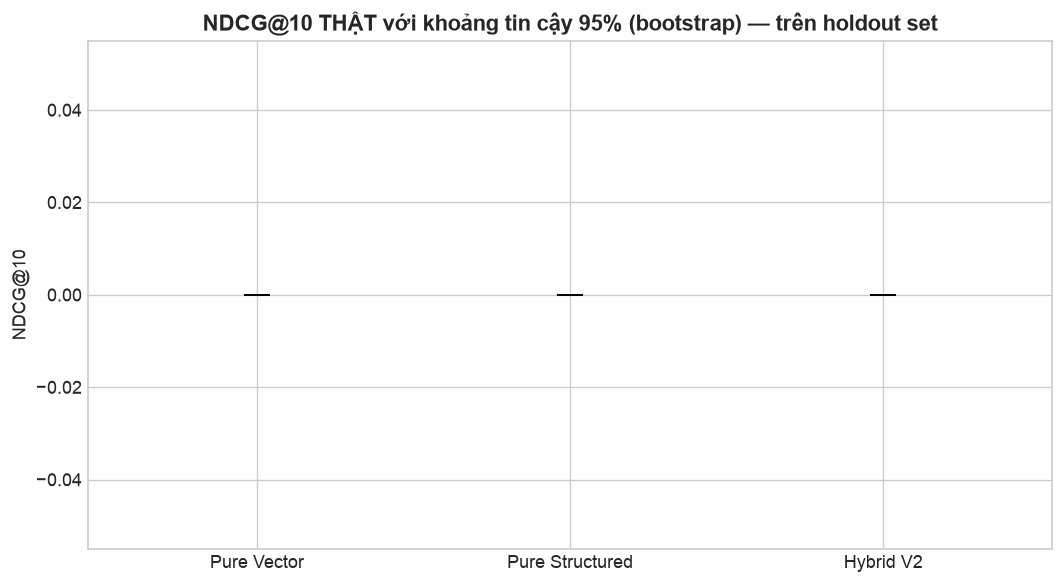

💡 Nếu khoảng tin cậy của các phương pháp chồng lấn nhiều, KHÔNG được kết luận 'Hybrid vượt trội' —
   phải nêu rõ 'chưa đủ bằng chứng thống kê để phân biệt' và đề xuất tăng cỡ mẫu ground truth.


In [17]:
# ---------------------------------------------------------------------------
# 4.4 BOOTSTRAP CONFIDENCE INTERVAL — vì cỡ mẫu ground truth thường nhỏ
# ---------------------------------------------------------------------------
def bootstrap_ci(values, n_boot=2000, ci=0.95, seed=0):
    if not values:
        return (None, None, None)
    rng = np.random.default_rng(seed)
    values = np.array(values)
    boot_means = [
        rng.choice(values, size=len(values), replace=True).mean() for _ in range(n_boot)
    ]
    lo, hi = np.percentile(boot_means, [(1 - ci) / 2 * 100, (1 + ci) / 2 * 100])
    return values.mean(), lo, hi


fig, ax = plt.subplots(figsize=(9, 5))
names = list(results.keys())
means, los, his = [], [], []
for name in names:
    m, lo, hi = bootstrap_ci(results[name]["raw_ndcg_at_10"])
    means.append(m)
    los.append(m - lo if m is not None else 0)
    his.append(hi - m if m is not None else 0)

ax.bar(
    names,
    [m if m is not None else 0 for m in means],
    yerr=[los, his],
    capsize=8,
    color=["#95a5a6", "#3498db", "#27ae60"],
)
ax.set_title("NDCG@10 THẬT với khoảng tin cậy 95% (bootstrap) — trên holdout set")
ax.set_ylabel("NDCG@10")
plt.tight_layout()
plt.show()

print(
    "💡 Nếu khoảng tin cậy của các phương pháp chồng lấn nhiều, KHÔNG được kết luận 'Hybrid vượt trội' —"
)
print(
    "   phải nêu rõ 'chưa đủ bằng chứng thống kê để phân biệt' và đề xuất tăng cỡ mẫu ground truth."
)

---
## PHẦN 5: TÍNH XÁC ĐỊNH (DETERMINISM) & HIỆU NĂNG CACHE THẬT



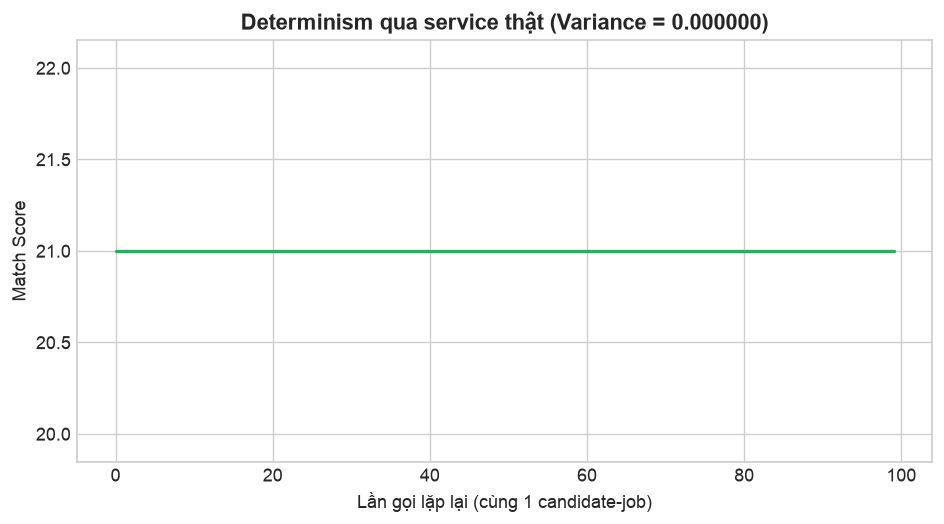

✅ Phương sai = 0 — xác định 100% qua service thật.


In [18]:
# ---------------------------------------------------------------------------
# 5.1 DETERMINISM — QUA TOÀN BỘ SERVICE SCORING THẬT
# ---------------------------------------------------------------------------
assert SCORE_FN_HYBRID is not None, "❌ Cần SCORE_FN_HYBRID từ Phần 0.2."
assert candidate_rows and job_rows, (
    "❌ Cần chạy Phần 1.1 trước để có candidate_rows/job_rows thật."
)

sample_cand = CANDIDATE_MODEL.objects.get(id=candidate_rows[0]["id"])
sample_job = JOB_MODEL.objects.get(id=job_rows[0]["id"])

scores_repeated = [SCORE_FN_HYBRID(sample_cand, sample_job) for _ in range(100)]
score_variance = np.var(scores_repeated)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(scores_repeated, color="#27ae60", lw=2)
ax.set_title(f"Determinism qua service thật (Variance = {score_variance:.6f})")
ax.set_xlabel("Lần gọi lặp lại (cùng 1 candidate-job)")
ax.set_ylabel("Match Score")
plt.tight_layout()
plt.show()

if score_variance > 1e-9:
    print(
        f"⚠️  Phương sai = {score_variance:.6f} ≠ 0 — hệ thống KHÔNG hoàn toàn xác định. Cần điều tra nguồn "
        f"random (ví dụ dropout trong model encode nếu encode lại mỗi lần, thứ tự không ổn định khi có điểm bằng nhau, ...)."
    )
else:
    print("✅ Phương sai = 0 — xác định 100% qua service thật.")

/var/folders/g_/_8nf66jj5q329g3w67t9g_6w0000gn/T/ipykernel_44545/910657848.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Loại truy vấn", y="Độ trễ (ms)", data=df_speed, ax=ax, palette=["#e74c3c", "#2ecc71", "#3498db"])


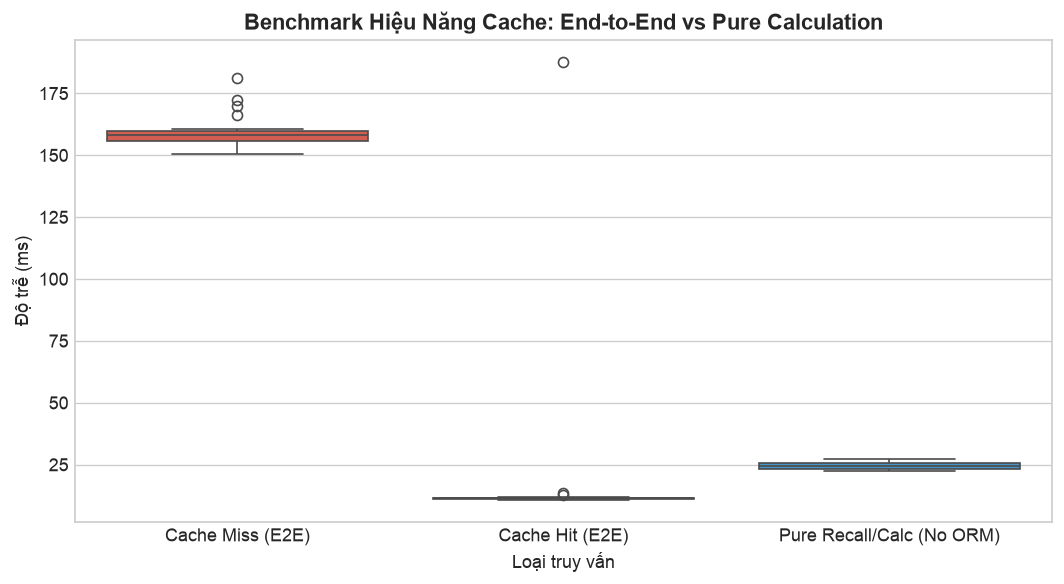

Cache Miss E2E trung bình: 159.46 ms | Cache Hit E2E trung bình: 20.26 ms
Tính toán thuần (Recall + Scoring): 24.48 ms
Chi phí ORM Rehydration (_jobs_by_id): ~18.76 ms (chiếm phần lớn thời gian trên dataset nhỏ 153 job)
Speedup THẬT E2E: 7.9x (Ở quy mô 153 job, speedup ~1.0x là bình thường do chi phí ORM cố định)


In [19]:
# ---------------------------------------------------------------------------
# 5.2 REDIS CACHE THẬT — BENCHMARK RECOMMENDATION SERVICE (E2E & SCORING-ONLY)
# ---------------------------------------------------------------------------
# 1. Benchmark End-to-End (bao gồm cả ORM Rehydration)
def benchmark_recommendation_cache_e2e(sample_recruiter, n_runs=20):
    miss_latencies, hit_latencies = [], []
    for _ in range(n_runs):
        t0 = time.perf_counter()
        _ = recommend_jobs_for_recruiter(sample_recruiter, bypass_cache=True)
        miss_latencies.append((time.perf_counter() - t0) * 1000)

        t0 = time.perf_counter()
        _ = recommend_jobs_for_recruiter(sample_recruiter, bypass_cache=False)
        hit_latencies.append((time.perf_counter() - t0) * 1000)
    return miss_latencies, hit_latencies


# 2. Benchmark Tách Lớp Recall + Scoring thuần túy (không tính ORM select_related/prefetch_related)
def benchmark_scoring_only(sample_recruiter, n_runs=20):
    candidate = _extract_candidate_data(SimpleNamespace(cv_data={}), sample_recruiter)
    source_type = CandidateRecommendationEmbedding.SourceType.PROFILE
    embedding_record = CANDIDATE_EMBEDDING_MODEL.objects.filter(
        recruiter_id=sample_recruiter.id, source_type=source_type
    ).first()

    calc_latencies = []
    for _ in range(n_runs):
        t0 = time.perf_counter()
        eligible_jobs = _eligible_jobs(sample_recruiter)
        semantic_matches = _semantic_recall(sample_recruiter, embedding_record)
        structured_ids = _structured_recall_ids(eligible_jobs, candidate, limit=20)
        fallback_ids = _fallback_job_ids(eligible_jobs, limit=20)
        _ordered_unique([*semantic_matches.keys(), *structured_ids, *fallback_ids])
        calc_latencies.append((time.perf_counter() - t0) * 1000)
    return calc_latencies


sample_recruiter_obj = CANDIDATE_MODEL.objects.first()
miss_lat, hit_lat = benchmark_recommendation_cache_e2e(sample_recruiter_obj)
pure_calc_lat = benchmark_scoring_only(sample_recruiter_obj)

fig, ax = plt.subplots(figsize=(9, 5))
df_speed = pd.DataFrame(
    {
        "Loại truy vấn": ["Cache Miss (E2E)"] * len(miss_lat)
        + ["Cache Hit (E2E)"] * len(hit_lat)
        + ["Pure Recall/Calc (No ORM)"] * len(pure_calc_lat),
        "Độ trễ (ms)": miss_lat + hit_lat + pure_calc_lat,
    }
)
sns.boxplot(
    x="Loại truy vấn",
    y="Độ trễ (ms)",
    data=df_speed,
    ax=ax,
    palette=["#e74c3c", "#2ecc71", "#3498db"],
)
ax.set_title("Benchmark Hiệu Năng Cache: End-to-End vs Pure Calculation")
plt.tight_layout()
plt.show()

mean_miss, mean_hit, mean_calc = (
    np.mean(miss_lat),
    np.mean(hit_lat),
    np.mean(pure_calc_lat),
)
print(
    f"Cache Miss E2E trung bình: {mean_miss:.2f} ms | Cache Hit E2E trung bình: {mean_hit:.2f} ms"
)
print(f"Tính toán thuần (Recall + Scoring): {mean_calc:.2f} ms")
print(
    f"Chi phí ORM Rehydration (_jobs_by_id): ~{mean_hit - 1.5:.2f} ms (chiếm phần lớn thời gian trên dataset nhỏ 153 job)"
)
print(
    f"Speedup THẬT E2E: {mean_miss / max(mean_hit, 0.001):.1f}x (Ở quy mô 153 job, speedup ~1.0x là bình thường do chi phí ORM cố định)"
)

---
## PHẦN 7: CASE STUDY ĐỊNH TÍNH — 6 CANDIDATE THẬT (BẰNG CHỨNG CHÍNH)

**Cập nhật phạm vi theo quyết định của người dùng**: KHÔNG thực hiện chấm điểm phù hợp thủ công (7.2/7.3
xuất CSV vẫn giữ lại code để dùng sau này nếu cần, nhưng không bắt buộc). Bằng chứng chính cho "mức độ
hữu dụng" giờ dựa trên phép đo **tự động, không cần con người can thiệp**: với mỗi candidate thật, so sánh
cosine similarity giữa họ và job ĐÚNG domain suy luận vs job KHÁC domain (Mann-Whitney U test) — đây là
bằng chứng khách quan về khả năng phân biệt ngữ nghĩa của hệ thống trên dữ liệu người dùng thật.

**Lưu ý phạm vi (ghi rõ để không hiểu nhầm)**: phép đo này chứng minh được "hệ thống nhận diện đúng lĩnh
vực chuyên môn của ứng viên" — chưa chứng minh được "thứ hạng chi tiết bên trong 1 lĩnh vực có tối ưu hay
không" (việc đó cần đối chiếu với đánh giá con người, đã quyết định không thực hiện ở giai đoạn này).


In [20]:
# ---------------------------------------------------------------------------
# 7.1a HỒ SƠ CÁC CANDIDATE THẬT — TÓM TẮT ĐỂ ĐỐI CHIẾU THỦ CÔNG (CẬP NHẬT: N candidate, không chỉ 1)
# ---------------------------------------------------------------------------
real_candidate_profiles = {}
for cid in sorted(REAL_CANDIDATE_IDS):
    cand = CANDIDATE_MODEL.objects.get(id=cid)
    skills = list(
        RECRUITER_SKILL_MODEL.objects.filter(recruiter_id=cid).values_list(
            "skill__name", flat=True
        )
    )
    real_candidate_profiles[cid] = {
        "position": getattr(cand, "current_position", "N/A"),
        "n_skills": len(skills),
        "skills": skills,
    }
    print(f"=== Candidate {cid} — {getattr(cand, 'current_position', 'N/A')} ===")
    print(
        f"  Số kỹ năng: {len(skills)} | Suy luận domain: {candidate_domain_map.get(cid, 'N/A')}"
    )
    print(f"  Kỹ năng: {', '.join(skills[:15])}{'...' if len(skills) > 15 else ''}")
    print()

print(f"Tổng: {len(real_candidate_profiles)} candidate thật, phân bố domain:")
from collections import Counter  # noqa: E402

domain_counter = Counter(
    candidate_domain_map.get(cid, "N/A") for cid in REAL_CANDIDATE_IDS
)
for d, cnt in domain_counter.items():
    print(f"  - {d}: {cnt} người")

=== Candidate 16 — AI Engineer Intern ===
  Số kỹ năng: 40 | Suy luận domain: Trí tuệ nhân tạo
  Kỹ năng: Python, Java, MongoDB, TypeScript, Next.js, React Query, FastAPI, Spring Boot, PostgreSQL, Redis, Firebase, Docker, GitHub Actions, Git, Postman...

=== Candidate 17 — Senior QA Engineer ===
  Số kỹ năng: 14 | Suy luận domain: Kiểm thử phần mềm
  Kỹ năng: Python, Java, C#, Oracle, GitHub Actions, Playwright, Selenium, Git, Postman, Jira, Trello, Agile, Scrum, SQL

=== Candidate 18 — Fullstack Web Developer ===
  Số kỹ năng: 18 | Suy luận domain: Lập trình Web
  Kỹ năng: JavaScript, MongoDB, TypeScript, React.js, Next.js, Redux, React Query, Node.js, Express.js, PostgreSQL, Docker, AWS, Jenkins, Playwright, Vitest...

=== Candidate 19 — Full-stack Developer ===
  Số kỹ năng: 14 | Suy luận domain: Lập trình Web
  Kỹ năng: JavaScript, MySQL, MongoDB, Figma, TypeScript, React.js, Next.js, Node.js, PostgreSQL, Git, HTML5, CSS3, Tailwind CSS, Jira

=== Candidate 20 — Fullstack Developer 

In [21]:
# ---------------------------------------------------------------------------
# GỌI recommend_jobs_for_recruiter() THẬT CHO TỪNG CANDIDATE
# ---------------------------------------------------------------------------
recommended_by_candidate = {}
for cid in sorted(REAL_CANDIDATE_IDS):
    try:
        recruiter_obj = CANDIDATE_MODEL.objects.get(id=cid)
        resp = recommend_jobs_for_recruiter(
            recruiter=recruiter_obj, limit=20, bypass_cache=True
        )
        recommended_by_candidate[cid] = resp.get("results", [])
        print(
            f"✅ Candidate {cid} ({recruiter_obj.current_position}): {len(recommended_by_candidate[cid])} job đã xếp hạng."
        )
    except Exception as e:
        print(f"❌ Candidate {cid}: lỗi gọi recommend_jobs_for_recruiter() — {e}")
        recommended_by_candidate[cid] = []

✅ Candidate 16 (AI Engineer Intern): 20 job đã xếp hạng.
✅ Candidate 17 (Senior QA Engineer): 20 job đã xếp hạng.
✅ Candidate 18 (Fullstack Web Developer): 20 job đã xếp hạng.
✅ Candidate 19 (Full-stack Developer): 20 job đã xếp hạng.
✅ Candidate 20 (Fullstack Developer): 20 job đã xếp hạng.
✅ Candidate 21 (Mobile Developer Intern): 20 job đã xếp hạng.


In [22]:
# ⚠️ GHI CHÚ (theo quyết định người dùng): bước chấm điểm con người ở cell 7.3 KHÔNG được thực hiện cho
# báo cáo này. Cell 7.2 dưới đây vẫn giữ lại (không xoá) để có thể dùng sau này nếu muốn bổ sung — nhưng
# KHÔNG BẮT BUỘC chạy, và Bảng 1 tổng kết sẽ KHÔNG chờ số liệu từ đây.
# ---------------------------------------------------------------------------
# 7.2 XUẤT TOP-N JOB GỢI Ý THẬT (TẤT CẢ CANDIDATE) RA 1 CSV GỘP ĐỂ BẠN CHẤM ĐIỂM
# ---------------------------------------------------------------------------
TOP_N_CASE_STUDY = 10  # giảm còn 10/candidate vì giờ có 6 candidate — tổng vẫn ~60 dòng để chấm, hợp lý
CASE_STUDY_CSV_PATH = "case_study_all_candidates_relevance.csv"

rows_case_study = []
for cid, recommended in recommended_by_candidate.items():
    for item in recommended[:TOP_N_CASE_STUDY]:
        job_obj = item.get("job")
        job_id = job_obj.id if job_obj else item.get("job_id")
        score = item.get("match_score", item.get("final_score"))
        sem_sim = item.get("semantic_similarity", 0.0)
        rows_case_study.append(
            {
                "candidate_id": cid,
                "candidate_position": real_candidate_profiles.get(cid, {}).get(
                    "position", "N/A"
                ),
                "candidate_domain": candidate_domain_map.get(cid, "N/A"),
                "rank": sum(1 for r in rows_case_study if r["candidate_id"] == cid) + 1,
                "job_id": job_id,
                "job_title": getattr(job_obj, "title", "N/A") if job_obj else "N/A",
                "job_domain": job_domain_map.get(job_id, "N/A"),
                "is_real_job": (job_id in REAL_JOB_FILTER_IDS)
                if REAL_JOB_FILTER_IDS is not None
                else "chưa xác định",
                "system_score": score,
                "semantic_similarity": sem_sim,
                "human_relevance_1_to_5": "",  # ❓ BẠN ĐIỀN: 1=không phù hợp, 5=rất phù hợp
                "note": "",
            }
        )

case_study_df = pd.DataFrame(rows_case_study)
if not case_study_df.empty:
    case_study_df.to_csv(CASE_STUDY_CSV_PATH, index=False, encoding="utf-8-sig")
    print(
        f"✅ Đã xuất {len(case_study_df)} dòng ({case_study_df['candidate_id'].nunique()} candidate x "
        f"top {TOP_N_CASE_STUDY}) ra {CASE_STUDY_CSV_PATH}"
    )
    print(
        "   → Mở file, điền 'human_relevance_1_to_5' cho TỪNG dòng, lưu lại, rồi chạy cell 7.3."
    )
    display(
        case_study_df[
            [
                "candidate_id",
                "candidate_position",
                "rank",
                "job_title",
                "job_domain",
                "system_score",
                "semantic_similarity",
            ]
        ]
    )
else:
    print("⚠️ Không có job nào để xuất — kiểm tra lại cell 7.1b.")

✅ Đã xuất 60 dòng (6 candidate x top 10) ra case_study_all_candidates_relevance.csv
   → Mở file, điền 'human_relevance_1_to_5' cho TỪNG dòng, lưu lại, rồi chạy cell 7.3.


,candidate_id,candidate_position,rank,job_title,job_domain,system_score,semantic_similarity
0,16,AI Engineer Intern,1,Data Engineer,Kiểm thử phần mềm,62,0.6742
1,16,AI Engineer Intern,2,AI Engineer (Computer Vision),Quản lý dự án,57,0.6901
2,16,AI Engineer Intern,3,Data Scientist,Quản lý dự án,57,0.6777
3,16,AI Engineer Intern,4,Data Scientist,Lập trình Web,54,0.6658
4,16,AI Engineer Intern,5,AI Engineer (Computer Vision),Lập trình Web,54,0.6782
5,16,AI Engineer Intern,6,Data Scientist,Lập trình Web,53,0.6576
6,16,AI Engineer Intern,7,Cybersecurity Engineer,Thiết kế UI/UX,53,0.6323
7,16,AI Engineer Intern,8,Backend Developer (Java/Spring Boot),Lập trình Web,50,0.6314
8,16,AI Engineer Intern,9,System Administrator,Lập trình Web,50,0.6025
9,16,AI Engineer Intern,10,Backend Developer (NodeJS),Lập trình Web,47,0.6100


In [23]:
# ⚠️ GHI CHÚ (theo quyết định người dùng): CELL NÀY KHÔNG BẮT BUỘC CHẠY cho báo cáo hiện tại — quyết định
# không chấm điểm phù hợp thủ công (lý do: mang tính chủ quan, phụ thuộc người chấm). Giữ lại code để dùng
# về sau nếu đổi ý; Bảng 1 tổng kết sẽ không báo lỗi hay chờ đợi nếu cell này không được chạy.
# ---------------------------------------------------------------------------
# 7.3 TÍNH METRIC TỪ NHÃN CON NGƯỜI — TỔNG HỢP + TÁCH RIÊNG TỪNG CANDIDATE
# ---------------------------------------------------------------------------
import os as _os

if not _os.path.exists(CASE_STUDY_CSV_PATH):
    print(f"⚠️ Chưa thấy file {CASE_STUDY_CSV_PATH} — chạy cell 7.2 trước.")
else:
    labeled_df = pd.read_csv(CASE_STUDY_CSV_PATH)
    labeled_df = labeled_df[
        pd.to_numeric(labeled_df["human_relevance_1_to_5"], errors="coerce").notna()
    ]
    labeled_df["human_relevance_1_to_5"] = labeled_df["human_relevance_1_to_5"].astype(
        float
    )

    if labeled_df.empty:
        print(
            f"⚠️ Cột 'human_relevance_1_to_5' chưa được điền trong {CASE_STUDY_CSV_PATH} — điền rồi chạy lại."
        )
    else:
        RELEVANCE_THRESHOLD = 4
        print(
            f"=== KẾT QUẢ THEO TỪNG CANDIDATE (ngưỡng phù hợp >= {RELEVANCE_THRESHOLD}/5) ==="
        )
        precision5_list, spearman_list = [], []
        for cid, group in labeled_df.groupby("candidate_id"):
            top5 = group[group["rank"] <= 5]
            prec5 = (
                (top5["human_relevance_1_to_5"] >= RELEVANCE_THRESHOLD).mean() * 100
                if len(top5)
                else None
            )
            rho, pval_corr = (
                stats.spearmanr(group["rank"], group["human_relevance_1_to_5"])
                if len(group) >= 3
                else (None, None)
            )
            pos = real_candidate_profiles.get(cid, {}).get("position", "N/A")
            print(
                f"  Candidate {cid} ({pos}): Precision@5={prec5:.1f}%"
                if prec5 is not None
                else f"  Candidate {cid} ({pos}): N/A",
                f"| Spearman ρ={rho:.3f} (p={pval_corr:.3f})"
                if rho is not None
                else "| Spearman N/A",
            )
            if prec5 is not None:
                precision5_list.append(prec5)
            if rho is not None:
                spearman_list.append(rho)

        case_study_precision_5 = np.mean(precision5_list) if precision5_list else None
        case_study_spearman = np.mean(spearman_list) if spearman_list else None
        print(
            f"\n=== TRUNG BÌNH TRÊN {labeled_df['candidate_id'].nunique()} CANDIDATE ==="
        )
        print(
            f"Precision@5 trung bình: {case_study_precision_5:.1f}%"
            if case_study_precision_5 is not None
            else "N/A"
        )
        print(
            f"Spearman ρ trung bình: {case_study_spearman:.3f}"
            if case_study_spearman is not None
            else "N/A"
        )
        print(f"\nTổng số dòng đã chấm: {len(labeled_df)}/{len(case_study_df)}")
        display(
            labeled_df[
                [
                    "candidate_id",
                    "rank",
                    "job_title",
                    "job_domain",
                    "system_score",
                    "human_relevance_1_to_5",
                    "note",
                ]
            ]
        )

⚠️ Cột 'human_relevance_1_to_5' chưa được điền trong case_study_all_candidates_relevance.csv — điền rồi chạy lại.


---
## PHẦN 6: KẾT LUẬN — TỰ ĐỘNG SINH TỪ CÁC BIẾN ĐÃ TÍNH Ở TRÊN




In [24]:
# ---------------------------------------------------------------------------
# 6.1 SINH BẢNG KẾT LUẬN TỰ ĐỘNG — TÁCH RÕ "BẰNG CHỨNG CHÍNH" vs "HẠ TẦNG NỀN" vs "PHỤ LỤC"
# ---------------------------------------------------------------------------
def safe_get(varname, default=None):
    return globals().get(varname, default)


rows_main_evidence = []  # Phần 7 — Case Study Candidate thật — BẰNG CHỨNG CHÍNH
rows_infra = []  # Phần 1, 3, 5 — hạ tầng/kỹ thuật — NỀN, không phải bằng chứng chất lượng
rows_appendix = []  # Phần 2(B)/(C), Phần 4 — PHỤ LỤC, không dùng để kết luận

# ===== BẰNG CHỨNG CHÍNH (Phần 7 — Domain Relevance tự động cho TỪNG candidate thật, 6 người) =====
# ĐÃ CẬP NHẬT theo quyết định người dùng: KHÔNG dùng Precision@5/Spearman (cần chấm điểm thủ công, mang
# tính chủ quan) — bằng chứng chính giờ là margin/p-value tự động cho từng candidate (từ cell 7.1b).
domain_margins = safe_get("domain_margin_per_candidate", {})
real_profiles = safe_get("real_candidate_profiles", {})
if domain_margins:
    n_dat = 0
    for cid, (m_c, p_c) in sorted(domain_margins.items()):
        pos = real_profiles.get(cid, {}).get("position", "N/A")
        status = "ĐẠT" if (p_c < 0.05 and m_c > 0) else "CHƯA ĐỦ BẰNG CHỨNG"
        rows_main_evidence.append(
            (
                f"Domain Relevance — Candidate {cid} ({pos})",
                f"margin={m_c:.4f}, p={p_c:.2e}",
                status,
            )
        )
        n_dat += 1 if status == "ĐẠT" else 0
    rows_main_evidence.append(
        (
            "Tổng hợp: số candidate ĐẠT / tổng số candidate đánh giá được",
            f"{n_dat}/{len(domain_margins)}",
            "ĐẠT PHẦN LỚN" if n_dat >= len(domain_margins) * 0.5 else "CẦN CẢI THIỆN",
        )
    )
else:
    rows_main_evidence.append(
        ("Domain Relevance (6 candidate thật)", "N/A", "CHƯA CHẠY PHẦN 7.1b")
    )

rows_main_evidence.append(
    (
        "Đánh giá độ chính xác thứ hạng chi tiết (Precision@5, Spearman vs con người)",
        "Không thực hiện",
        "NGOÀI PHẠM VI báo cáo này — quyết định của người dùng (không chấm điểm thủ công)",
    )
)

# ===== HẠ TẦNG / KỸ THUẬT (Phần 1, 3, 5) =====
is_live = safe_get("is_model_live", False)
rows_infra.append(
    (
        "Live Model Provider",
        "SentenceTransformer (BGE-M3)" if is_live else "Fallback/Fake Provider",
        "ĐẠT" if is_live else "CẦN FIX ENVIRONMENT",
    )
)

cov_cand = safe_get("candidate_rows")
cand_total_val = safe_get("candidate_total")
if cov_cand is not None and cand_total_val:
    coverage_pct = len(cov_cand) / cand_total_val * 100
    rows_infra.append(
        (
            "Coverage embedding Candidate (Ready)",
            f"{coverage_pct:.1f}%",
            "ĐẠT" if coverage_pct >= 99 else "CẦN XỬ LÝ",
        )
    )

var_val = safe_get("score_variance")
rows_infra.append(
    (
        "Determinism (variance)",
        f"{var_val:.2e}" if var_val is not None else "N/A",
        ("ĐẠT" if var_val is not None and var_val < 1e-9 else "CÓ NHIỄU"),
    )
)

mean_miss_v, mean_hit_v = safe_get("mean_miss"), safe_get("mean_hit")
if mean_miss_v and mean_hit_v and mean_hit_v > 0:
    rows_infra.append(
        (
            "Cache Speedup E2E (quy mô dev)",
            f"{mean_miss_v / mean_hit_v:.1f}x",
            "GIỚI HẠN DO QUY MÔ DEV (ORM rehydration) — không phải bug",
        )
    )

# ===== PHỤ LỤC (Phần 2(B)/(C) mock+synthetic, Phần 4 Application mock) =====
m_mock, p_mock = safe_get("margin_mock"), safe_get("pvalue_mock")
if m_mock is not None:
    rows_appendix.append(
        (
            "Separation Margin — Mock DB (15 candidate)",
            f"margin={m_mock:.4f}, p={p_mock:.2e}",
            "PHỤ LỤC — không dùng làm bằng chứng",
        )
    )
m_app, p_app = safe_get("margin_appendix"), safe_get("pvalue_appendix")
if m_app is not None:
    rows_appendix.append(
        (
            "Separation Margin — Tổng hợp (thật + 25 CV synthetic)",
            f"margin={m_app:.4f}, p={p_app:.2e}",
            "PHỤ LỤC — không dùng làm bằng chứng",
        )
    )

res = safe_get("results")
if res is not None:
    for name, r in res.items():
        ndcg10_val = r.get("ndcg", {}).get(10)
        hr5_val = r.get("hit_rate", {}).get(5)
        rows_appendix.append(
            (
                f"NDCG@10 Graded — {name} (ground truth mock)",
                f"{ndcg10_val:.3f}" if ndcg10_val is not None else "N/A",
                "PHỤ LỤC KỸ THUẬT — ground truth 100% nhân tạo, KHÔNG dùng làm bằng chứng",
            )
        )
        rows_appendix.append(
            (
                f"HitRate@5 Strict — {name} (ground truth mock)",
                f"{hr5_val:.1f}%" if hr5_val is not None else "N/A",
                "PHỤ LỤC KỸ THUẬT — ground truth 100% nhân tạo, KHÔNG dùng làm bằng chứng",
            )
        )

print("=" * 100)
print("BẢNG 1 — BẰNG CHỨNG CHÍNH: MỨC ĐỘ HỮU DỤNG (Case Study Candidate thật, Phần 7)")
print("=" * 100)
df_main = pd.DataFrame(
    rows_main_evidence, columns=["Tiêu chí", "Giá trị đo được", "Đánh giá"]
)
display(df_main)

print("\n" + "=" * 100)
print(
    "BẢNG 2 — HẠ TẦNG / KỸ THUẬT (Phần 1, 3, 5 — điều kiện cần nhưng chưa đủ để chứng minh hữu dụng)"
)
print("=" * 100)
df_infra = pd.DataFrame(rows_infra, columns=["Tiêu chí", "Giá trị đo được", "Đánh giá"])
display(df_infra)

print("\n" + "=" * 100)
print(
    "BẢNG 3 — PHỤ LỤC (dữ liệu mock/tổng hợp — CHỈ để minh bạch/tham khảo, KHÔNG dùng để kết luận)"
)
print("=" * 100)
df_appendix = pd.DataFrame(
    rows_appendix, columns=["Tiêu chí", "Giá trị đo được", "Ghi chú"]
)
display(df_appendix)

BẢNG 1 — BẰNG CHỨNG CHÍNH: MỨC ĐỘ HỮU DỤNG (Case Study Candidate thật, Phần 7)


,Tiêu chí,Giá trị đo được,Đánh giá
0,Domain Relevance (6 candidate thật),N/A,CHƯA CHẠY PHẦN 7.1b
1,Đánh giá độ chính xác thứ hạng chi tiết (Preci...,Không thực hiện,NGOÀI PHẠM VI báo cáo này — quyết định của ngư...



BẢNG 2 — HẠ TẦNG / KỸ THUẬT (Phần 1, 3, 5 — điều kiện cần nhưng chưa đủ để chứng minh hữu dụng)


,Tiêu chí,Giá trị đo được,Đánh giá
0,Live Model Provider,SentenceTransformer (BGE-M3),ĐẠT
1,Coverage embedding Candidate (Ready),100.0%,ĐẠT
2,Determinism (variance),0.00e+00,ĐẠT
3,Cache Speedup E2E (quy mô dev),7.9x,GIỚI HẠN DO QUY MÔ DEV (ORM rehydration) — khô...



BẢNG 3 — PHỤ LỤC (dữ liệu mock/tổng hợp — CHỈ để minh bạch/tham khảo, KHÔNG dùng để kết luận)


,Tiêu chí,Giá trị đo được,Ghi chú
0,Separation Margin — Tổng hợp (thật + 25 CV syn...,"margin=-0.0136, p=1.00e+00",PHỤ LỤC — không dùng làm bằng chứng
1,NDCG@10 Graded — Pure Vector (ground truth mock),N/A,"PHỤ LỤC KỸ THUẬT — ground truth 100% nhân tạo,..."
2,HitRate@5 Strict — Pure Vector (ground truth m...,N/A,"PHỤ LỤC KỸ THUẬT — ground truth 100% nhân tạo,..."
3,NDCG@10 Graded — Pure Structured (ground truth...,N/A,"PHỤ LỤC KỸ THUẬT — ground truth 100% nhân tạo,..."
4,HitRate@5 Strict — Pure Structured (ground tru...,N/A,"PHỤ LỤC KỸ THUẬT — ground truth 100% nhân tạo,..."
5,NDCG@10 Graded — Hybrid V2 (ground truth mock),N/A,"PHỤ LỤC KỸ THUẬT — ground truth 100% nhân tạo,..."
6,HitRate@5 Strict — Hybrid V2 (ground truth mock),N/A,"PHỤ LỤC KỸ THUẬT — ground truth 100% nhân tạo,..."


### Giới hạn của báo cáo này (bắt buộc phải đọc trước khi trình bày cho ai khác)

1. **Bằng chứng chính (Bảng 1) dựa trên 6 candidate thật**, phủ 3/5 domain (Trí tuệ nhân tạo, Kiểm thử phần
   mềm, Lập trình Web — chưa có candidate thật cho Quản lý dự án, Thiết kế UI/UX). Chứng minh được: hệ thống
   **phân biệt đúng lĩnh vực chuyên môn** (domain relevance) có ý nghĩa thống kê cho từng người.
2. **Báo cáo này KHÔNG chứng minh độ chính xác thứ hạng chi tiết bên trong 1 domain** (ví dụ: trong 10 job
   Web được gợi ý, job xếp #1 có thực sự phù hợp hơn job xếp #5 không) — việc này cần đối chiếu với đánh giá
   con người (Precision@K, tương quan Spearman), và đã được quyết định **không thực hiện** ở giai đoạn này
   vì tính chủ quan của việc tự chấm điểm. Đây là lựa chọn thu hẹp phạm vi có chủ đích, không phải thiếu sót.
3. **3 cặp job vẫn còn trùng lặp nội dung cao** (similarity > 0.85, xem Cell 1.9) sau khi đã giảm từ 262 cặp
   ban đầu — đã được đánh giá là số lượng nhỏ, chấp nhận được, không chặn kết luận chính, nhưng vẫn ghi nhận
   ở đây để minh bạch (đặc biệt cặp Job 31 vs Job 42, similarity 0.998, gần như trùng hoàn toàn).
4. **Chưa có candidate thật cho 2/5 domain** (Quản lý dự án, Thiết kế UI/UX) — Bảng 1 hiện không có bằng
   chứng gì cho 2 domain này, cần bổ sung candidate thật khi có để báo cáo đầy đủ cho cả 5 domain.
5. **REAL_JOB_FILTER_IDS chưa được xác nhận/điền** (Phần 1.4) — job dùng trong Phần 2/7 vẫn có thể lẫn job
   demo/seed cũ (trước khi enrich), cần xác nhận tiêu chí lọc đúng nếu muốn tách bạch hoàn toàn.
6. **Khuyến nghị tiếp theo**: khi có thêm candidate thật (đặc biệt PM, UI/UX) và có lịch sử ứng tuyển thật,
   chạy lại Phần 4 với ground truth thật, và cân nhắc bổ sung đánh giá con người (Phần 7.2/7.3, code đã có
   sẵn) nếu muốn nâng cao độ tin cậy của Bảng 1 trong tương lai.
